Métricas que debes cuidar especialmente

Las tres más importantes para no confundirte son estas:

estimated_edge_usdc != PnL final

Eso sólo mide si el fill fue bueno contra el mid_before.

unenriched != taker

Sólo significa que aún no tienes maker/taker para ese fill.

sum_price_approx < 1 no prueba arbitraje automáticamente

Es candidato. Necesitas emparejar fills por tiempo, tamaño y condición.

In [1]:
# leer los dos csv (diferentes cuentas misma estructura)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Configure pandas to display more columns and less scientific notation
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.5f' % x)

# Define paths for the CSV files (assuming they are in the content directory)
GAP_FILE = Path('/content/gap_maker_taker.csv')
RN1_FILE = Path('/content/rn1_maker_taker.csv')

print(f"GAP_FILE path: {GAP_FILE}")
print(f"RN1_FILE path: {RN1_FILE}")

GAP_FILE path: /content/gap_maker_taker.csv
RN1_FILE path: /content/rn1_maker_taker.csv


In [3]:
gap_raw = pd.read_csv(GAP_FILE)
rn1_raw = pd.read_csv(RN1_FILE)

print("\n--- GAP RAW Dataframe ---")
print("Shape:", gap_raw.shape)
print("Columns:", gap_raw.columns.tolist())
print("First 3 rows:\n", gap_raw.head(3))
# Convert 'trade_utc' to datetime for proper min/max calculation
gap_raw['trade_utc'] = pd.to_datetime(gap_raw['trade_utc'])
print("trade_utc min:", gap_raw['trade_utc'].min())
print("trade_utc max:", gap_raw['trade_utc'].max())

print("\n--- RN1 RAW Dataframe ---")
print("Shape:", rn1_raw.shape)
print("Columns:", rn1_raw.columns.tolist())
print("First 3 rows:\n", rn1_raw.head(3))
# Convert 'trade_utc' to datetime for proper min/max calculation
rn1_raw['trade_utc'] = pd.to_datetime(rn1_raw['trade_utc'])
print("trade_utc min:", rn1_raw['trade_utc'].min())
print("trade_utc max:", rn1_raw['trade_utc'].max())


--- GAP RAW Dataframe ---
Shape: (312, 25)
Columns: ['trade_utc', 'wallet', 'role', 'side', 'token_id', 'outcome_label', 'question', 'fill_price', 'fill_size', 'delta_usdc', 'book_before_utc', 'book_before_age_s', 'best_bid_before', 'best_ask_before', 'spread_before', 'mid_before', 'book_after_utc', 'book_after_age_s', 'best_bid_after', 'best_ask_after', 'spread_after', 'mid_after', 'context_status', 'edge_vs_mid_before', 'estimated_edge_usdc']
First 3 rows:
              trade_utc                                      wallet   role  \
0  2026-07-04 19:01:56  0x83255595ba1fadd2e734cb30a0fb8110301a19cc  maker   
1  2026-07-04 19:01:53  0x83255595ba1fadd2e734cb30a0fb8110301a19cc  maker   
2  2026-07-04 19:01:52  0x83255595ba1fadd2e734cb30a0fb8110301a19cc  maker   

  side                                           token_id outcome_label  \
0  BUY  1060966262649843185184094716764671364173179968...            No   
1  BUY  1060966262649843185184094716764671364173179968...            No   
2

In [4]:
required_columns = [
    'trade_utc', 'wallet', 'role', 'side', 'token_id', 'outcome_label', 'question', 'fill_price', 'fill_size', 'delta_usdc',
    'book_before_utc', 'book_before_age_s', 'best_bid_before', 'best_ask_before', 'spread_before', 'mid_before',
    'book_after_utc', 'book_after_age_s', 'best_bid_after', 'best_ask_after', 'spread_after', 'mid_after',
    'context_status', 'edge_vs_mid_before', 'estimated_edge_usdc'
]

def validate_columns(df, df_name, required_cols):
    df_columns = set(df.columns)
    required_cols_set = set(required_cols)

    missing_columns = required_cols_set - df_columns
    extra_columns = df_columns - required_cols_set

    if missing_columns:
        raise ValueError(f"Error: Dataframe '{df_name}' is missing required columns: {sorted(list(missing_columns))}")

    if extra_columns:
        print(f"Warning: Dataframe '{df_name}' has extra columns: {sorted(list(extra_columns))}")

    print(f"Dataframe '{df_name}' has all required columns and no unexpected extras.\n")

# Validate gap_raw
validate_columns(gap_raw, "gap_raw", required_columns)

# Validate rn1_raw
validate_columns(rn1_raw, "rn1_raw", required_columns)

Dataframe 'gap_raw' has all required columns and no unexpected extras.

Dataframe 'rn1_raw' has all required columns and no unexpected extras.



In [6]:
def clean_fills(df, label):
    # 1. Copia el dataframe.
    df_cleaned = df.copy()

    # 2. Agrega columna wallet_label con el valor recibido.
    df_cleaned['wallet_label'] = label

    # 3. Convierte trade_utc, book_before_utc y book_after_utc a datetime
    datetime_cols = ['trade_utc', 'book_before_utc', 'book_after_utc']
    for col in datetime_cols:
        df_cleaned[col] = pd.to_datetime(df_cleaned[col], errors='coerce', utc=False) # Keep as naive for now, or convert to UTC if explicit.

    # 4. Convierte a numérico:
    numeric_cols = [
        'fill_price', 'fill_size', 'delta_usdc',
        'book_before_age_s', 'best_bid_before', 'best_ask_before', 'spread_before', 'mid_before',
        'book_after_age_s', 'best_bid_after', 'best_ask_after', 'spread_after', 'mid_after',
        'edge_vs_mid_before', 'estimated_edge_usdc'
    ]
    for col in numeric_cols:
        df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce')

    # 5. Normaliza role, side y context_status a minúsculas.
    string_cols_to_lower = ['role', 'side', 'context_status']
    for col in string_cols_to_lower:
        df_cleaned[col] = df_cleaned[col].astype(str).str.lower()

    # 6. Agrega notional = abs(delta_usdc).
    df_cleaned['notional'] = df_cleaned['delta_usdc'].abs()

    # 7. Agrega signed_shares = fill_size si side == buy, -fill_size si side == sell.
    df_cleaned['signed_shares'] = np.where(
        df_cleaned['side'] == 'buy',
        df_cleaned['fill_size'],
        np.where(df_cleaned['side'] == 'sell', -df_cleaned['fill_size'], np.nan)
    )

    # 8. Agrega valid_before_book = book_before_age_s no nulo y <= 60.
    df_cleaned['valid_before_book'] = df_cleaned['book_before_age_s'].notna() & (df_cleaned['book_before_age_s'] <= 60)

    # 9. Agrega strict_before_book = book_before_age_s <= 15.
    df_cleaned['strict_before_book'] = df_cleaned['book_before_age_s'] <= 15

    # 10. Agrega is_buy, is_sell, is_maker, is_taker, is_unenriched.
    df_cleaned['is_buy'] = df_cleaned['side'] == 'buy'
    df_cleaned['is_sell'] = df_cleaned['side'] == 'sell'
    df_cleaned['is_maker'] = df_cleaned['role'] == 'maker'
    df_cleaned['is_taker'] = df_cleaned['role'] == 'taker'
    df_cleaned['is_unenriched'] = df_cleaned['role'] == 'unenriched'

    return df_cleaned

# Aplica la función a gap_raw y rn1_raw como gap y rn1.
gap = clean_fills(gap_raw, 'Mind.The.Gap')
rn1 = clean_fills(rn1_raw, 'RN1')

# Luego concatena en fills.
fills = pd.concat([gap, rn1], ignore_index=True)

# Imprime dtypes y una muestra.
print("\n--- FILLS Dataframe dtypes ---")
print(fills.dtypes)

print("\n--- FILLS Dataframe Sample (first 5 rows) ---")
print(fills.head())


--- FILLS Dataframe dtypes ---
trade_utc              datetime64[ns]
wallet                         object
role                           object
side                           object
token_id                       object
outcome_label                  object
question                       object
fill_price                    float64
fill_size                     float64
delta_usdc                    float64
book_before_utc        datetime64[ns]
book_before_age_s               int64
best_bid_before               float64
best_ask_before               float64
spread_before                 float64
mid_before                    float64
book_after_utc         datetime64[ns]
book_after_age_s              float64
best_bid_after                float64
best_ask_after                float64
spread_after                  float64
mid_after                     float64
context_status                 object
edge_vs_mid_before            float64
estimated_edge_usdc           float64
wallet_label      

In [7]:
quality_report = pd.DataFrame()

for label in fills['wallet_label'].unique():
    df_wallet = fills[fills['wallet_label'] == label].copy()
    report_data = {'wallet_label': label}

    # Filas totales
    report_data['total_rows'] = len(df_wallet)

    # trade_utc min/max
    report_data['trade_utc_min'] = df_wallet['trade_utc'].min()
    report_data['trade_utc_max'] = df_wallet['trade_utc'].max()

    # Columnas con null count
    null_counts = df_wallet.isnull().sum()
    for col, count in null_counts[null_counts > 0].items():
        report_data[f'null_count_{col}'] = count

    # Conteo por role
    role_counts = df_wallet['role'].value_counts(dropna=False)
    for role, count in role_counts.items():
        report_data[f'role_count_{role}'] = count

    # Conteo por side
    side_counts = df_wallet['side'].value_counts(dropna=False)
    for side, count in side_counts.items():
        report_data[f'side_count_{side}'] = count

    # Conteo por context_status
    context_counts = df_wallet['context_status'].value_counts(dropna=False)
    for status, count in context_counts.items():
        report_data[f'context_status_count_{status}'] = count

    # Porcentaje con valid_before_book
    report_data['pct_valid_before_book'] = (df_wallet['valid_before_book'].sum() / len(df_wallet)) * 100

    # Porcentaje con strict_before_book
    report_data['pct_strict_before_book'] = (df_wallet['strict_before_book'].sum() / len(df_wallet)) * 100

    # Filas con fill_price fuera de [0,1]
    report_data['fills_price_out_of_range'] = df_wallet[(df_wallet['fill_price'] < 0) | (df_wallet['fill_price'] > 1)].shape[0]

    # Filas con mid_before fuera de [0,1]
    report_data['mid_before_out_of_range'] = df_wallet[(df_wallet['mid_before'] < 0) | (df_wallet['mid_before'] > 1)].shape[0]

    # Filas con fill_size <= 0
    report_data['fill_size_le_0'] = df_wallet[df_wallet['fill_size'] <= 0].shape[0]

    # Filas con notional <= 0
    report_data['notional_le_0'] = df_wallet[df_wallet['notional'] <= 0].shape[0]

    quality_report = pd.concat([quality_report, pd.DataFrame([report_data])], ignore_index=True)

print("--- Quality Report by Wallet Label ---")
# Transponer el reporte para una mejor legibilidad si hay muchas columnas
# y manejar NaN en la transposición para no imprimir "NaN" para valores no presentes.
quality_report = quality_report.set_index('wallet_label').T.fillna('-')
print(quality_report)

--- Quality Report by Wallet Label ---
wallet_label                           Mind.The.Gap                  RN1
total_rows                                      312                 3979
trade_utc_min                   2026-07-04 17:31:46  2026-07-04 11:20:38
trade_utc_max                   2026-07-04 19:01:56  2026-07-04 21:39:37
null_count_best_ask_before                        1                    6
null_count_spread_before                          1                    6
null_count_mid_before                             1                    6
null_count_best_ask_after                         6                   84
null_count_spread_after                           6                   84
null_count_mid_after                              6                   84
null_count_edge_vs_mid_before                     1                    6
null_count_estimated_edge_usdc                    1                    6
role_count_maker                                273                 3707
role_count_t

In [8]:
summary_by_wallet = []

for label in fills['wallet_label'].unique():
    df_wallet = fills[fills['wallet_label'] == label].copy()

    total_fills = len(df_wallet)
    first_trade = df_wallet['trade_utc'].min()
    last_trade = df_wallet['trade_utc'].max()
    duration_minutes = (last_trade - first_trade).total_seconds() / 60 if first_trade and last_trade else 0
    unique_tokens = df_wallet['token_id'].nunique()
    unique_questions = df_wallet['question'].nunique()
    buy_fills = df_wallet['is_buy'].sum()
    sell_fills = df_wallet['is_sell'].sum()
    maker_fills = df_wallet['is_maker'].sum()
    taker_fills = df_wallet['is_taker'].sum()
    unenriched_fills = df_wallet['is_unenriched'].sum()
    notional_total = df_wallet['notional'].sum()
    estimated_edge_total = df_wallet['estimated_edge_usdc'].sum()

    # Avoid division by zero for edge_bps
    edge_bps = (estimated_edge_total / notional_total * 10000) if notional_total > 0 else 0

    # Percentage of fills with estimated_edge_usdc > 0
    positive_edge_share = (df_wallet['estimated_edge_usdc'] > 0).sum() / total_fills * 100 if total_fills > 0 else 0

    # Percentage of fills with strict_context_share
    strict_context_share = df_wallet['strict_before_book'].sum() / total_fills * 100 if total_fills > 0 else 0

    # Percentage of fills with valid_context_share
    valid_context_share = df_wallet['valid_before_book'].sum() / total_fills * 100 if total_fills > 0 else 0

    summary_by_wallet.append({
        'wallet_label': label,
        'fills': total_fills,
        'first_trade': first_trade,
        'last_trade': last_trade,
        'duration_minutes': duration_minutes,
        'unique_tokens': unique_tokens,
        'unique_questions': unique_questions,
        'buy_fills': buy_fills,
        'sell_fills': sell_fills,
        'maker_fills': maker_fills,
        'taker_fills': taker_fills,
        'unenriched_fills': unenriched_fills,
        'notional_total': notional_total,
        'estimated_edge_total': estimated_edge_total,
        'edge_bps': edge_bps,
        'positive_edge_share': positive_edge_share,
        'strict_context_share': strict_context_share,
        'valid_context_share': valid_context_share
    })

summary_by_wallet_df = pd.DataFrame(summary_by_wallet)

# Order by notional_total descending and round numbers
summary_by_wallet_df = summary_by_wallet_df.sort_values(by='notional_total', ascending=False)
summary_by_wallet_df = summary_by_wallet_df.round({
    'duration_minutes': 2,
    'notional_total': 2,
    'estimated_edge_total': 2,
    'edge_bps': 2,
    'positive_edge_share': 2,
    'strict_context_share': 2,
    'valid_context_share': 2
})

print("--- Summary by Wallet Label ---")
print(summary_by_wallet_df)

--- Summary by Wallet Label ---
   wallet_label  fills         first_trade          last_trade  \
1           RN1   3979 2026-07-04 11:20:38 2026-07-04 21:39:37   
0  Mind.The.Gap    312 2026-07-04 17:31:46 2026-07-04 19:01:56   

   duration_minutes  unique_tokens  unique_questions  buy_fills  sell_fills  \
1         618.98000            162                96       3979           0   
0          90.17000             17                10        234          78   

   maker_fills  taker_fills  unenriched_fills  notional_total  \
1         3707           79               193   1210480.08000   
0          273           39                 0    197869.82000   

   estimated_edge_total  edge_bps  positive_edge_share  strict_context_share  \
1           16501.99000 136.33000             90.98000              92.39000   
0           -1970.78000 -99.60000             70.83000             100.00000   

   valid_context_share  
1            100.00000  
0            100.00000  


In [9]:
# Calcula la ventana común entre Mind.The.Gap y RN1
common_start = fills.groupby('wallet_label')['trade_utc'].min().max()
common_end = fills.groupby('wallet_label')['trade_utc'].max().min()

# Filtra fills a esa ventana común
fills_common_window = fills[(fills['trade_utc'] >= common_start) & (fills['trade_utc'] <= common_end)].copy()

# Recalcula la duración en minutos para la ventana común
duration_common_minutes = (common_end - common_start).total_seconds() / 60

print(f"Common Start (UTC): {common_start}")
print(f"Common End (UTC): {common_end}")
print(f"Duration of Common Window (minutes): {duration_common_minutes:.2f}\n")

# Crea la misma tabla resumen de la celda anterior, pero sólo para esa ventana.
summary_by_wallet_common_window = []

for label in fills_common_window['wallet_label'].unique():
    df_wallet_common = fills_common_window[fills_common_window['wallet_label'] == label].copy()

    total_fills = len(df_wallet_common)
    first_trade = df_wallet_common['trade_utc'].min()
    last_trade = df_wallet_common['trade_utc'].max()
    duration_minutes = (last_trade - first_trade).total_seconds() / 60 if first_trade and last_trade else 0
    unique_tokens = df_wallet_common['token_id'].nunique()
    unique_questions = df_wallet_common['question'].nunique()
    buy_fills = df_wallet_common['is_buy'].sum()
    sell_fills = df_wallet_common['is_sell'].sum()
    maker_fills = df_wallet_common['is_maker'].sum()
    taker_fills = df_wallet_common['is_taker'].sum()
    unenriched_fills = df_wallet_common['is_unenriched'].sum()
    notional_total = df_wallet_common['notional'].sum()
    estimated_edge_total = df_wallet_common['estimated_edge_usdc'].sum()

    edge_bps = (estimated_edge_total / notional_total * 10000) if notional_total > 0 else 0
    positive_edge_share = (df_wallet_common['estimated_edge_usdc'] > 0).sum() / total_fills * 100 if total_fills > 0 else 0
    strict_context_share = df_wallet_common['strict_before_book'].sum() / total_fills * 100 if total_fills > 0 else 0
    valid_context_share = df_wallet_common['valid_before_book'].sum() / total_fills * 100 if total_fills > 0 else 0

    summary_by_wallet_common_window.append({
        'wallet_label': label,
        'fills': total_fills,
        'first_trade': first_trade,
        'last_trade': last_trade,
        'duration_minutes': duration_minutes,
        'unique_tokens': unique_tokens,
        'unique_questions': unique_questions,
        'buy_fills': buy_fills,
        'sell_fills': sell_fills,
        'maker_fills': maker_fills,
        'taker_fills': taker_fills,
        'unenriched_fills': unenriched_fills,
        'notional_total': notional_total,
        'estimated_edge_total': estimated_edge_total,
        'edge_bps': edge_bps,
        'positive_edge_share': positive_edge_share,
        'strict_context_share': strict_context_share,
        'valid_context_share': valid_context_share
    })

summary_common_window_df = pd.DataFrame(summary_by_wallet_common_window)

# Order by notional_total descending and round numbers
summary_common_window_df = summary_common_window_df.sort_values(by='notional_total', ascending=False)
summary_common_window_df = summary_common_window_df.round({
    'duration_minutes': 2,
    'notional_total': 2,
    'estimated_edge_total': 2,
    'edge_bps': 2,
    'positive_edge_share': 2,
    'strict_context_share': 2,
    'valid_context_share': 2
})

print("--- Summary by Wallet Label (Common Window) ---")
print(summary_common_window_df)

Common Start (UTC): 2026-07-04 17:31:46
Common End (UTC): 2026-07-04 19:01:56
Duration of Common Window (minutes): 90.17

--- Summary by Wallet Label (Common Window) ---
   wallet_label  fills         first_trade          last_trade  \
1           RN1   2578 2026-07-04 17:32:34 2026-07-04 19:01:29   
0  Mind.The.Gap    312 2026-07-04 17:31:46 2026-07-04 19:01:56   

   duration_minutes  unique_tokens  unique_questions  buy_fills  sell_fills  \
1          88.92000             80                47       2578           0   
0          90.17000             17                10        234          78   

   maker_fills  taker_fills  unenriched_fills  notional_total  \
1         2513           56                 9    762638.49000   
0          273           39                 0    197869.82000   

   estimated_edge_total  edge_bps  positive_edge_share  strict_context_share  \
1           11343.27000 148.74000             90.26000              91.58000   
0           -1970.78000 -99.60000    

In [10]:
def create_grouped_summary(df, df_name):
    grouped_summary = df.groupby(['wallet_label', 'role', 'side']).agg(
        fills=('wallet', 'size'),
        notional=('notional', 'sum'),
        estimated_edge_usdc=('estimated_edge_usdc', 'sum'),
        avg_fill_price=('fill_price', 'mean'),
        avg_mid_before=('mid_before', 'mean'),
        positive_edge_count=('estimated_edge_usdc', lambda x: (x > 0).sum()),
        strict_context_count=('strict_before_book', 'sum')
    )

    grouped_summary['edge_bps'] = (grouped_summary['estimated_edge_usdc'] / grouped_summary['notional'] * 10000).fillna(0)
    grouped_summary['avg_edge_per_fill'] = (grouped_summary['estimated_edge_usdc'] / grouped_summary['fills']).fillna(0)
    grouped_summary['positive_edge_share'] = (grouped_summary['positive_edge_count'] / grouped_summary['fills'] * 100).fillna(0)
    grouped_summary['strict_context_share'] = (grouped_summary['strict_context_count'] / grouped_summary['fills'] * 100).fillna(0)

    # Drop intermediate columns
    grouped_summary = grouped_summary.drop(columns=['positive_edge_count', 'strict_context_count'])

    # Round numerical columns for better readability
    grouped_summary = grouped_summary.round({
        'notional': 2,
        'estimated_edge_usdc': 2,
        'edge_bps': 2,
        'avg_edge_per_fill': 2,
        'avg_fill_price': 4,
        'avg_mid_before': 4,
        'positive_edge_share': 2,
        'strict_context_share': 2
    })

    print(f"--- Grouped Summary by Wallet, Role, Side ({df_name}) ---")
    print(grouped_summary)
    print("\n")

# 1. Dataset completo
create_grouped_summary(fills, "Complete Dataset")

# 2. Ventana común
create_grouped_summary(fills_common_window, "Common Window")

--- Grouped Summary by Wallet, Role, Side (Complete Dataset) ---
                              fills      notional  estimated_edge_usdc  \
wallet_label role       side                                             
Mind.The.Gap maker      buy     208  104748.77000           -300.76000   
                        sell     65   24537.86000            142.36000   
             taker      buy      26   43722.45000          -1210.56000   
                        sell     13   24860.73000           -601.83000   
RN1          maker      buy    3707 1105647.23000          16303.50000   
             taker      buy      79   61964.58000           -249.81000   
             unenriched buy     193   42868.26000            448.30000   

                              avg_fill_price  avg_mid_before   edge_bps  \
wallet_label role       side                                              
Mind.The.Gap maker      buy          0.71130         0.69120  -28.71000   
                        sell         0.4389

In [11]:
# Calcula edge_vs_mid_calc y estimated_edge_calc
fills['edge_vs_mid_calc'] = np.where(
    fills['side'] == 'buy', fills['mid_before'] - fills['fill_price'],
    np.where(fills['side'] == 'sell', fills['fill_price'] - fills['mid_before'], np.nan)
)
fills['estimated_edge_calc'] = fills['edge_vs_mid_calc'] * fills['fill_size']

# Crea columnas de diferencia
fills['edge_diff'] = fills['edge_vs_mid_before'] - fills['edge_vs_mid_calc']
fills['estimated_edge_diff'] = fills['estimated_edge_usdc'] - fills['estimated_edge_calc']

# Muestra máximo absoluto de edge_diff
print(f"Máximo absoluto de edge_diff: {fills['edge_diff'].abs().max():.6f}")

# Muestra máximo absoluto de estimated_edge_diff
print(f"Máximo absoluto de estimated_edge_diff: {fills['estimated_edge_diff'].abs().max():.6f}")

# Filas con diferencia mayor a 1e-6
diff_threshold = 1e-6
issues_edge = fills[fills['edge_diff'].abs() > diff_threshold]
issues_estimated_edge = fills[fills['estimated_edge_diff'].abs() > diff_threshold]

if not issues_edge.empty:
    print(f"\nFilas con edge_diff mayor a {diff_threshold}:")
    print(issues_edge[['wallet_label', 'side', 'fill_price', 'mid_before', 'edge_vs_mid_before', 'edge_vs_mid_calc', 'edge_diff']].head())
else:
    print(f"\nNo hay filas con edge_diff mayor a {diff_threshold}.")

if not issues_estimated_edge.empty:
    print(f"\nFilas con estimated_edge_diff mayor a {diff_threshold}:")
    print(issues_estimated_edge[['wallet_label', 'side', 'fill_price', 'mid_before', 'fill_size', 'estimated_edge_usdc', 'estimated_edge_calc', 'estimated_edge_diff']].head())
else:
    print(f"\nNo hay filas con estimated_edge_diff mayor a {diff_threshold}.")

Máximo absoluto de edge_diff: 0.000000
Máximo absoluto de estimated_edge_diff: 0.000000

No hay filas con edge_diff mayor a 1e-06.

No hay filas con estimated_edge_diff mayor a 1e-06.


In [12]:
# Filtra fills con strict_before_book == True
fills_strict_context = fills[fills['strict_before_book'] == True].copy()

# Filtra fills con valid_before_book == True
fills_valid_context = fills[fills['valid_before_book'] == True].copy()

def create_filtered_summary(df, df_name):
    grouped_summary = df.groupby(['wallet_label', 'role', 'side']).agg(
        fills=('wallet', 'size'),
        notional=('notional', 'sum'),
        estimated_edge_usdc=('estimated_edge_usdc', 'sum'),
        edge_bps=('estimated_edge_usdc', lambda x: (x.sum() / df.loc[x.index, 'notional'].sum() * 10000) if df.loc[x.index, 'notional'].sum() > 0 else 0),
        positive_edge_share=('estimated_edge_usdc', lambda x: (x > 0).sum() / len(x) * 100 if len(x) > 0 else 0),
        avg_book_before_age_s=('book_before_age_s', 'mean'),
        avg_spread_before=('spread_before', 'mean'),
        avg_fill_price=('fill_price', 'mean'),
        avg_mid_before=('mid_before', 'mean')
    )

    grouped_summary = grouped_summary.round({
        'notional': 2,
        'estimated_edge_usdc': 2,
        'edge_bps': 2,
        'positive_edge_share': 2,
        'avg_book_before_age_s': 2,
        'avg_spread_before': 5,
        'avg_fill_price': 5,
        'avg_mid_before': 5
    })

    print(f"--- Summary by Wallet, Role, Side ({df_name}) ---")
    print(grouped_summary)
    print("\n")

# Genera resumen para strict_before_book
create_filtered_summary(fills_strict_context, "Strict Before Book (age <= 15s)")

# Genera resumen para valid_before_book
create_filtered_summary(fills_valid_context, "Valid Before Book (age <= 60s)")

--- Summary by Wallet, Role, Side (Strict Before Book (age <= 15s)) ---
                              fills      notional  estimated_edge_usdc  \
wallet_label role       side                                             
Mind.The.Gap maker      buy     208  104748.77000           -300.76000   
                        sell     65   24537.86000            142.36000   
             taker      buy      26   43722.45000          -1210.56000   
                        sell     13   24860.73000           -601.83000   
RN1          maker      buy    3416 1029313.32000          15040.71000   
             taker      buy      68   56649.90000           -374.66000   
             unenriched buy     192   42737.90000            447.89000   

                               edge_bps  positive_edge_share  \
wallet_label role       side                                   
Mind.The.Gap maker      buy   -28.71000             72.60000   
                        sell   58.02000             87.69000   
     

--- Distribution of book_before_age_s by Wallet Label ---

Wallet: Mind.The.Gap
                        fills  percentage
book_before_age_bucket                   
0s                         85    27.24000
1-5s                      208    66.67000
6-15s                      19     6.09000
16-30s                      0     0.00000
31-60s                      0     0.00000
>60s                        0     0.00000
missing                     0     0.00000

Wallet: Mind.The.Gap (by Role)
  Role: maker
                        fills  percentage
book_before_age_bucket                   
0s                         80    29.30000
1-5s                      178    65.20000
6-15s                      15     5.49000
16-30s                      0     0.00000
31-60s                      0     0.00000
>60s                        0     0.00000
missing                     0     0.00000
  Role: taker
                        fills  percentage
book_before_age_bucket                   
0s                  

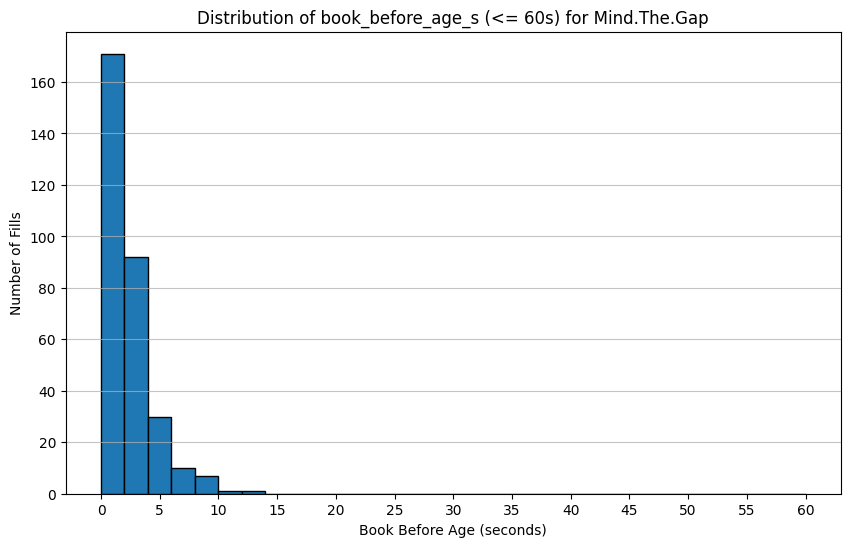

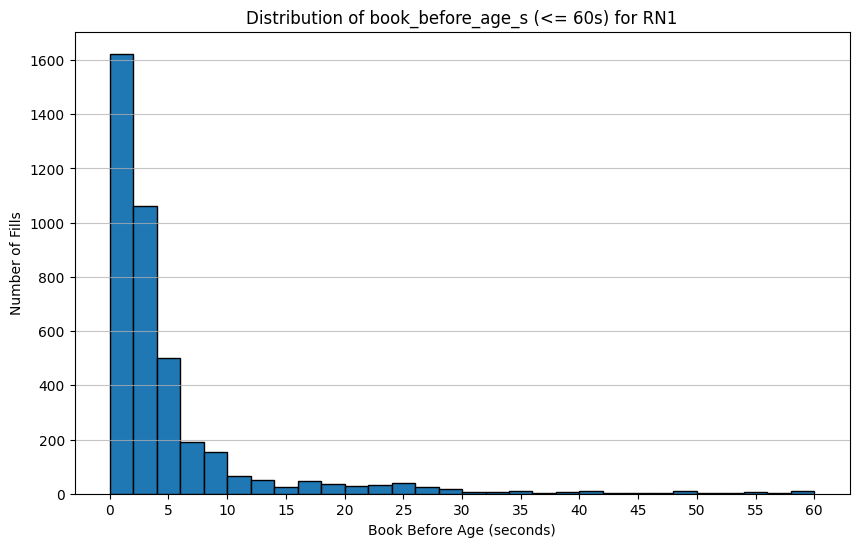

In [13]:
# Define the buckets for book_before_age_s
def get_age_bucket(age):
    if pd.isna(age): return 'missing'
    if age == 0: return '0s'
    if 1 <= age <= 5: return '1-5s'
    if 6 <= age <= 15: return '6-15s'
    if 16 <= age <= 30: return '16-30s'
    if 31 <= age <= 60: return '31-60s'
    if age > 60: return '>60s'
    return 'missing'

fills['book_before_age_bucket'] = fills['book_before_age_s'].apply(get_age_bucket)

bucket_order = ['0s', '1-5s', '6-15s', '16-30s', '31-60s', '>60s', 'missing']

print("--- Distribution of book_before_age_s by Wallet Label ---")
for wallet_label in fills['wallet_label'].unique():
    df_wallet = fills[fills['wallet_label'] == wallet_label]

    # Distribution for the entire wallet
    wallet_dist = df_wallet['book_before_age_bucket'].value_counts(normalize=True).reindex(bucket_order, fill_value=0)
    wallet_fills = df_wallet['book_before_age_bucket'].value_counts().reindex(bucket_order, fill_value=0)

    print(f"\nWallet: {wallet_label}")
    print(pd.DataFrame({'fills': wallet_fills, 'percentage': wallet_dist.mul(100).round(2)}))

    # Distribution by role within the wallet
    print(f"\nWallet: {wallet_label} (by Role)")
    for role in df_wallet['role'].unique():
        df_role = df_wallet[df_wallet['role'] == role]
        if not df_role.empty:
            role_dist = df_role['book_before_age_bucket'].value_counts(normalize=True).reindex(bucket_order, fill_value=0)
            role_fills = df_role['book_before_age_bucket'].value_counts().reindex(bucket_order, fill_value=0)
            print(f"  Role: {role}")
            print(pd.DataFrame({'fills': role_fills, 'percentage': role_dist.mul(100).round(2)}))

# Histograms for book_before_age_s <= 60
print("\n--- Histograms for book_before_age_s (<= 60s) ---")
plt.style.use('default') # Use default style for matplotlib plots

for wallet_label in fills['wallet_label'].unique():
    # Filter data for ages <= 60s and non-missing
    df_plot = fills[(fills['wallet_label'] == wallet_label) & (fills['book_before_age_s'] <= 60)].copy()
    if not df_plot.empty:
        plt.figure(figsize=(10, 6))
        plt.hist(df_plot['book_before_age_s'], bins=range(0, 62, 2), edgecolor='black')
        plt.title(f'Distribution of book_before_age_s (<= 60s) for {wallet_label}')
        plt.xlabel('Book Before Age (seconds)')
        plt.ylabel('Number of Fills')
        plt.xticks(range(0, 61, 5))
        plt.grid(axis='y', alpha=0.75)
        plt.show()
    else:
        print(f"No data for {wallet_label} with book_before_age_s <= 60 for histogram.")

In [14]:
grouped_by_question = fills.groupby(['wallet_label', 'question']).agg(
    fills=('wallet', 'size'),
    notional=('notional', 'sum'),
    estimated_edge_usdc=('estimated_edge_usdc', 'sum'),
    first_trade=('trade_utc', 'min'),
    last_trade=('trade_utc', 'max'),
    unique_tokens=('token_id', 'nunique'),
    buy_fills=('is_buy', 'sum'),
    sell_fills=('is_sell', 'sum'),
    maker_fills=('is_maker', 'sum'),
    taker_fills=('is_taker', 'sum'),
    unenriched_fills=('is_unenriched', 'sum')
).reset_index()

# Calculate duration_minutes
grouped_by_question['duration_minutes'] = (
    (grouped_by_question['last_trade'] - grouped_by_question['first_trade']).dt.total_seconds() / 60
)

# Calculate edge_bps, handling division by zero
grouped_by_question['edge_bps'] = np.where(
    grouped_by_question['notional'] > 0,
    (grouped_by_question['estimated_edge_usdc'] / grouped_by_question['notional']) * 10000,
    0
)

# Round numerical columns for better readability
grouped_by_question = grouped_by_question.round({
    'notional': 2,
    'estimated_edge_usdc': 2,
    'duration_minutes': 2,
    'edge_bps': 2
})

print("--- Top 20 Questions by Notional for Each Wallet ---")
for wallet_label in grouped_by_question['wallet_label'].unique():
    print(f"\nWallet: {wallet_label}")
    df_wallet = grouped_by_question[grouped_by_question['wallet_label'] == wallet_label]
    top_20_questions = df_wallet.sort_values(by='notional', ascending=False).head(20)
    print(top_20_questions.to_string())

print("\nThis analysis helps to see if a wallet's activity is concentrated in a few events or diversified.")

--- Top 20 Questions by Notional for Each Wallet ---

Wallet: Mind.The.Gap
   wallet_label                                 question  fills    notional  estimated_edge_usdc         first_trade          last_trade  unique_tokens  buy_fills  sell_fills  maker_fills  taker_fills  unenriched_fills  duration_minutes    edge_bps
3  Mind.The.Gap              Canada vs. Morocco: O/U 2.5     77 51917.54000           1882.82000 2026-07-04 18:13:29 2026-07-04 18:49:55              2         33          44           73            4                 0          36.43000   362.66000
4  Mind.The.Gap      Canada vs. Morocco: Team to Advance    101 47193.52000            360.95000 2026-07-04 17:31:46 2026-07-04 18:48:59              2         99           2           96            5                 0          77.22000    76.48000
9  Mind.The.Gap          Will Morocco win on 2026-07-04?     32 42649.06000          -2026.27000 2026-07-04 18:13:29 2026-07-04 18:49:25              2         28           4    

In [15]:
grouped_by_outcome = fills.groupby(['wallet_label', 'question', 'outcome_label', 'token_id']).agg(
    fills=('wallet', 'size'),
    net_shares=('signed_shares', 'sum'),
    gross_shares=('fill_size', 'sum'),
    notional=('notional', 'sum'),
    total_fill_price_times_size=('fill_price', lambda x: (x * fills.loc[x.index, 'fill_size']).sum()),
    estimated_edge_usdc=('estimated_edge_usdc', 'sum'),
    first_trade=('trade_utc', 'min'),
    last_trade=('trade_utc', 'max'),
    maker_fills=('is_maker', 'sum'),
    taker_fills=('is_taker', 'sum'),
    unenriched_fills=('is_unenriched', 'sum'),
    buy_fills=('is_buy', 'sum'),
    sell_fills=('is_sell', 'sum')
).reset_index()

# Calculate weighted_avg_price
grouped_by_outcome['weighted_avg_price'] = np.where(
    grouped_by_outcome['gross_shares'] > 0,
    grouped_by_outcome['total_fill_price_times_size'] / grouped_by_outcome['gross_shares'],
    np.nan
)

# Calculate edge_bps, handling division by zero
grouped_by_outcome['edge_bps'] = np.where(
    grouped_by_outcome['notional'] > 0,
    (grouped_by_outcome['estimated_edge_usdc'] / grouped_by_outcome['notional']) * 10000,
    0
)

# Drop the intermediate column
grouped_by_outcome = grouped_by_outcome.drop(columns=['total_fill_price_times_size'])

# Round numerical columns for better readability
grouped_by_outcome = grouped_by_outcome.round({
    'net_shares': 2,
    'gross_shares': 2,
    'notional': 2,
    'weighted_avg_price': 4,
    'estimated_edge_usdc': 2,
    'edge_bps': 2
})

print("--- Top 30 Questions by Notional for Each Wallet (Detailed by Outcome) ---")
for wallet_label in grouped_by_outcome['wallet_label'].unique():
    print(f"\nWallet: {wallet_label}")
    df_wallet = grouped_by_outcome[grouped_by_outcome['wallet_label'] == wallet_label]
    top_30_outcomes = df_wallet.sort_values(by='notional', ascending=False).head(30)
    print(top_30_outcomes.to_string())

print("\nThis table provides a granular view of trading activity at the question and outcome level, allowing for deeper insights into specific markets.")

--- Top 30 Questions by Notional for Each Wallet (Detailed by Outcome) ---

Wallet: Mind.The.Gap
    wallet_label                                 question outcome_label                                                                        token_id  fills  net_shares  gross_shares    notional  estimated_edge_usdc         first_trade          last_trade  maker_fills  taker_fills  unenriched_fills  buy_fills  sell_fills  weighted_avg_price    edge_bps
8   Mind.The.Gap      Canada vs. Morocco: Team to Advance       Morocco  101238961791599951615685057841199539507679732083288763835613798393210363728749     84 48969.50000   50079.48000 44617.84000            244.08000 2026-07-04 18:13:29 2026-07-04 18:48:59           82            2                 0         83           1             0.88990    54.71000
5   Mind.The.Gap              Canada vs. Morocco: O/U 2.5          Over   92558617592610075024809620259581225959591222778250295886163453827086930306302     56     0.05000   99828.82000 2765

In [16]:
# Group by wallet_label, question, outcome_label to get outcome-level metrics
outcome_level_metrics = fills.groupby(['wallet_label', 'question', 'outcome_label']).agg(
    net_shares=('signed_shares', 'sum'),
    notional=('notional', 'sum'),
    total_fill_price_times_size=('fill_price', lambda x: (x * fills.loc[x.index, 'fill_size']).sum()),
    gross_shares=('fill_size', 'sum'),
    fills=('wallet', 'size'),
    first_trade=('trade_utc', 'min'),
    last_trade=('trade_utc', 'max')
).reset_index()

# Calculate weighted_avg_price for each outcome
outcome_level_metrics['weighted_avg_price'] = np.where(
    outcome_level_metrics['gross_shares'] > 0,
    outcome_level_metrics['total_fill_price_times_size'] / outcome_level_metrics['gross_shares'],
    np.nan
)
outcome_level_metrics = outcome_level_metrics.drop(columns=['total_fill_price_times_size', 'gross_shares'])

print("--- Outcome-Level Metrics by Wallet, Question, Outcome ---")
print(outcome_level_metrics.round({
    'net_shares': 2, 'notional': 2, 'weighted_avg_price': 4
}).head())
print("\n")

# Aggregate to question level to identify binary questions
question_level_summary = outcome_level_metrics.groupby(['wallet_label', 'question']).agg(
    outcomes_operated=('outcome_label', 'nunique'),
    notional_total=('notional', 'sum'),
    min_weighted_avg_price=('weighted_avg_price', 'min'),
    max_weighted_avg_price=('weighted_avg_price', 'max'),
    all_outcome_details=('outcome_label', lambda x: list(zip(x, outcome_level_metrics.loc[x.index, 'weighted_avg_price'], outcome_level_metrics.loc[x.index, 'net_shares'])))
).reset_index()

# Identify binary questions
question_level_summary['is_binary_candidate'] = question_level_summary['outcomes_operated'] == 2

# For binary questions, calculate sum_price_approx, paired_qty_approx, imbalance_qty, paired_notional_proxy
def calculate_binary_metrics(row):
    if row['is_binary_candidate']:
        outcome1_price = row['all_outcome_details'][0][1]
        outcome2_price = row['all_outcome_details'][1][1]
        outcome1_net_shares = row['all_outcome_details'][0][2]
        outcome2_net_shares = row['all_outcome_details'][1][2]

        row['sum_price_approx'] = outcome1_price + outcome2_price
        row['paired_qty_approx'] = min(abs(outcome1_net_shares), abs(outcome2_net_shares))
        row['imbalance_qty'] = abs(abs(outcome1_net_shares) - abs(outcome2_net_shares))
        row['paired_notional_proxy'] = row['paired_qty_approx'] * row['sum_price_approx']
    else:
        row['sum_price_approx'] = np.nan
        row['paired_qty_approx'] = np.nan
        row['imbalance_qty'] = np.nan
        row['paired_notional_proxy'] = np.nan
    return row

question_level_summary = question_level_summary.apply(calculate_binary_metrics, axis=1)

# Drop the intermediate 'all_outcome_details' column
question_level_summary = question_level_summary.drop(columns=['all_outcome_details'])

# Round numerical columns for better readability
question_level_summary = question_level_summary.round({
    'notional_total': 2,
    'min_weighted_avg_price': 4,
    'max_weighted_avg_price': 4,
    'sum_price_approx': 4,
    'paired_qty_approx': 2,
    'imbalance_qty': 2,
    'paired_notional_proxy': 2
})

print("--- Question-Level Summary with Binary Metrics ---")
for wallet_label in question_level_summary['wallet_label'].unique():
    print(f"\nWallet: {wallet_label}")
    df_wallet_questions = question_level_summary[question_level_summary['wallet_label'] == wallet_label]
    print(df_wallet_questions.sort_values(by='notional_total', ascending=False).head(10).to_string())

print("\nThis summary identifies questions that are binary candidates and provides metrics related to potential completion-set trading.")

--- Outcome-Level Metrics by Wallet, Question, Outcome ---
   wallet_label                                 question outcome_label  \
0  Mind.The.Gap  Canada vs. Morocco: Both Teams to Score            No   
1  Mind.The.Gap  Canada vs. Morocco: Both Teams to Score           Yes   
2  Mind.The.Gap              Canada vs. Morocco: O/U 0.5          Over   
3  Mind.The.Gap              Canada vs. Morocco: O/U 1.5          Over   
4  Mind.The.Gap              Canada vs. Morocco: O/U 1.5         Under   

   net_shares    notional  fills         first_trade          last_trade  \
0   684.39000   670.70000      5 2026-07-04 19:01:49 2026-07-04 19:01:56   
1     5.72000 17126.20000     27 2026-07-04 18:13:29 2026-07-04 18:43:44   
2   634.56000   533.03000      5 2026-07-04 18:13:29 2026-07-04 18:13:31   
3   474.09000  9782.69000     21 2026-07-04 18:13:29 2026-07-04 18:45:31   
4  6248.65000  3154.06000      5 2026-07-04 18:16:20 2026-07-04 18:45:23   

   weighted_avg_price  
0             0

In [17]:
# Identify completion-set candidates
completion_candidates = question_level_summary[
    (question_level_summary['is_binary_candidate'] == True) &
    (question_level_summary['sum_price_approx'] < 1.00) &
    (question_level_summary['paired_qty_approx'] > 0) &
    (question_level_summary['notional_total'] > 100) # Threshold for reasonable notional
].copy()

# Calculate additional metrics for completion-set candidates
completion_candidates['theoretical_pair_edge_per_share'] = 1 - completion_candidates['sum_price_approx']
completion_candidates['theoretical_pair_edge_usdc'] = completion_candidates['paired_qty_approx'] * completion_candidates['theoretical_pair_edge_per_share']
completion_candidates['imbalance_ratio'] = completion_candidates['imbalance_qty'] / (completion_candidates['paired_qty_approx'] + completion_candidates['imbalance_qty'])

# Round numerical columns for better readability
completion_candidates = completion_candidates.round({
    'notional_total': 2,
    'min_weighted_avg_price': 4,
    'max_weighted_avg_price': 4,
    'sum_price_approx': 4,
    'paired_qty_approx': 2,
    'imbalance_qty': 2,
    'paired_notional_proxy': 2,
    'theoretical_pair_edge_per_share': 4,
    'theoretical_pair_edge_usdc': 2,
    'imbalance_ratio': 4
})

# Order by theoretical_pair_edge_usdc descending
completion_candidates = completion_candidates.sort_values(by='theoretical_pair_edge_usdc', ascending=False).reset_index(drop=True)

print("--- Completion-Set Candidates (Approximate) ---")
print("Note: These are approximations based on grouped average prices, not fill-by-fill matching.")
for wallet_label in completion_candidates['wallet_label'].unique():
    print(f"\nWallet: {wallet_label}")
    df_wallet_candidates = completion_candidates[completion_candidates['wallet_label'] == wallet_label]
    print(df_wallet_candidates.to_string())

if completion_candidates.empty:
    print("\nNo completion-set candidates found based on the defined criteria.")

--- Completion-Set Candidates (Approximate) ---
Note: These are approximations based on grouped average prices, not fill-by-fill matching.

Wallet: RN1
   wallet_label                                               question  outcomes_operated  notional_total  min_weighted_avg_price  max_weighted_avg_price  is_binary_candidate  sum_price_approx  paired_qty_approx  imbalance_qty  paired_notional_proxy  theoretical_pair_edge_per_share  theoretical_pair_edge_usdc  imbalance_ratio
0           RN1                  Paraguay vs. France: 1st Half O/U 1.5                  2     48458.45000                 0.22700                 0.67090                 True           0.89790        31711.60000    29769.25000            28473.38000                          0.10210                  3237.75000          0.48420
1           RN1                            France leading at halftime?                  2     65097.72000                 0.46840                 0.50210                 True           0.97060

In [18]:
# Filtra RN1 para questions que contengan 'Paraguay' o 'France'.
rn1_filtered_events = fills[
    (fills['wallet_label'] == 'RN1') &
    ((fills['question'].str.contains('Paraguay', case=False)) |
     (fills['question'].str.contains('France', case=False)))].copy()

# 1. Tabla ordenada por trade_utc con detalles fill-by-fill
fill_by_fill_details_rn1 = rn1_filtered_events[[
    'trade_utc', 'question', 'outcome_label', 'role', 'side', 'fill_price',
    'fill_size', 'notional', 'book_before_age_s', 'best_bid_before',
    'best_ask_before', 'mid_before', 'spread_before', 'edge_vs_mid_before',
    'estimated_edge_usdc'
]].sort_values(by='trade_utc').reset_index(drop=True)

print("--- RN1: Fill-by-Fill Details for Paraguay/France Events ---")
print(fill_by_fill_details_rn1.to_string())
print("\n")

# 2. Resumen por question/outcome_label
summary_rn1_events = rn1_filtered_events.groupby(['question', 'outcome_label']).agg(
    fills=('wallet', 'size'),
    net_shares=('signed_shares', 'sum'),
    gross_shares=('fill_size', 'sum'),
    notional=('notional', 'sum'),
    total_fill_price_times_size=('fill_price', lambda x: (x * rn1_filtered_events.loc[x.index, 'fill_size']).sum()),
    estimated_edge_usdc=('estimated_edge_usdc', 'sum'),
    first_trade=('trade_utc', 'min'),
    last_trade=('trade_utc', 'max')
).reset_index()

# Calculate weighted_avg_price
summary_rn1_events['weighted_avg_price'] = np.where(
    summary_rn1_events['gross_shares'] > 0,
    summary_rn1_events['total_fill_price_times_size'] / summary_rn1_events['gross_shares'],
    np.nan
)

# Calculate edge_bps, handling division by zero
summary_rn1_events['edge_bps'] = np.where(
    summary_rn1_events['notional'] > 0,
    (summary_rn1_events['estimated_edge_usdc'] / summary_rn1_events['notional']) * 10000,
    0
)

# Drop the intermediate column
summary_rn1_events = summary_rn1_events.drop(columns=['total_fill_price_times_size'])

# Round numerical columns for better readability
summary_rn1_events = summary_rn1_events.round({
    'net_shares': 2,
    'gross_shares': 2,
    'notional': 2,
    'weighted_avg_price': 4,
    'estimated_edge_usdc': 2,
    'edge_bps': 2
})

print("--- RN1: Summary by Question/Outcome for Paraguay/France Events ---")
print(summary_rn1_events.sort_values(by='notional', ascending=False).to_string())

print("\nObjetivo: entender si RN1 construyó una canasta del evento y no sólo una posición aislada.")

--- RN1: Fill-by-Fill Details for Paraguay/France Events ---
               trade_utc                                           question     outcome_label        role side  fill_price   fill_size    notional  book_before_age_s  best_bid_before  best_ask_before  mid_before  spread_before  edge_vs_mid_before  estimated_edge_usdc
0    2026-07-04 17:39:46  Wimbledon ATP: Frances Tiafoe vs Alexander Bublik    Frances Tiafoe       maker  buy     0.64000  1142.73000   731.34720                  6          0.64000          0.65000     0.64500        0.01000             0.00500              5.71365
1    2026-07-04 17:42:29  Wimbledon ATP: Frances Tiafoe vs Alexander Bublik    Frances Tiafoe       maker  buy     0.66000   744.10000   491.10600                 26          0.64000          0.65000     0.64500        0.01000            -0.01500            -11.16150
2    2026-07-04 17:47:43  Wimbledon ATP: Frances Tiafoe vs Alexander Bublik    Frances Tiafoe       maker  buy     0.63000   740.78378 

In [19]:
# Filtra Mind.The.Gap para questions que contengan 'Canada' o 'Morocco'.
mind_the_gap_filtered_events = fills[
    (fills['wallet_label'] == 'Mind.The.Gap') &
    ((fills['question'].str.contains('Canada', case=False)) |
     (fills['question'].str.contains('Morocco', case=False)))].copy()

# 1. Tabla ordenada por trade_utc con detalles fill-by-fill
fill_by_fill_details_mind_the_gap = mind_the_gap_filtered_events[[
    'trade_utc', 'question', 'outcome_label', 'role', 'side', 'fill_price',
    'fill_size', 'notional', 'book_before_age_s', 'best_bid_before',
    'best_ask_before', 'mid_before', 'spread_before', 'edge_vs_mid_before',
    'estimated_edge_usdc'
]].sort_values(by='trade_utc').reset_index(drop=True)

print("--- Mind.The.Gap: Fill-by-Fill Details for Canada/Morocco Events ---")
print(fill_by_fill_details_mind_the_gap.to_string())
print("\n")

# 2. Resumen por question/outcome_label
summary_mind_the_gap_events = mind_the_gap_filtered_events.groupby(['question', 'outcome_label']).agg(
    fills=('wallet', 'size'),
    net_shares=('signed_shares', 'sum'),
    gross_shares=('fill_size', 'sum'),
    notional=('notional', 'sum'),
    total_fill_price_times_size=('fill_price', lambda x: (x * mind_the_gap_filtered_events.loc[x.index, 'fill_size']).sum()),
    estimated_edge_usdc=('estimated_edge_usdc', 'sum'),
    first_trade=('trade_utc', 'min'),
    last_trade=('trade_utc', 'max')
).reset_index()

# Calculate weighted_avg_price
summary_mind_the_gap_events['weighted_avg_price'] = np.where(
    summary_mind_the_gap_events['gross_shares'] > 0,
    summary_mind_the_gap_events['total_fill_price_times_size'] / summary_mind_the_gap_events['gross_shares'],
    np.nan
)

# Calculate edge_bps, handling division by zero
summary_mind_the_gap_events['edge_bps'] = np.where(
    summary_mind_the_gap_events['notional'] > 0,
    (summary_mind_the_gap_events['estimated_edge_usdc'] / summary_mind_the_gap_events['notional']) * 10000,
    0
)

# Drop the intermediate column
summary_mind_the_gap_events = summary_mind_the_gap_events.drop(columns=['total_fill_price_times_size'])

# Round numerical columns for better readability
summary_mind_the_gap_events = summary_mind_the_gap_events.round({
    'net_shares': 2,
    'gross_shares': 2,
    'notional': 2,
    'weighted_avg_price': 4,
    'estimated_edge_usdc': 2,
    'edge_bps': 2
})

print("--- Mind.The.Gap: Summary by Question/Outcome for Canada/Morocco Events ---")
print(summary_mind_the_gap_events.sort_values(by='notional', ascending=False).to_string())

print("\nObjetivo: entender si Mind.The.Gap construyó una canasta del evento y no sólo una posición aislada, y si actúa como market maker simétrico o acumulador.")

--- Mind.The.Gap: Fill-by-Fill Details for Canada/Morocco Events ---
              trade_utc                                 question outcome_label   role  side  fill_price   fill_size    notional  book_before_age_s  best_bid_before  best_ask_before  mid_before  spread_before  edge_vs_mid_before  estimated_edge_usdc
0   2026-07-04 17:31:46      Canada vs. Morocco: Team to Advance        Canada  taker   buy     0.40000    11.00000     4.47920                  7          0.39000          0.40000     0.39500        0.01000            -0.00500             -0.05500
1   2026-07-04 18:13:29              Canada vs. Morocco: O/U 2.5          Over  maker   buy     0.22000    25.06410     5.51410                  1          0.12000          0.13000     0.12500        0.01000            -0.09500             -2.38109
2   2026-07-04 18:13:29                   Spread: Morocco (-1.5)       Morocco  maker   buy     0.20000    37.18750     7.43750                  9          0.09000          0.11000    

In [ ]:
Crea una serie temporal por wallet_label ordenada por trade_utc.

Calcula columnas acumuladas:
- cum_notional
- cum_estimated_edge_usdc
- cum_fills
- cum_buy_notional
- cum_sell_notional
- cum_maker_notional
- cum_taker_notional

Grafica con matplotlib:
1. cum_notional por tiempo, una gráfica por wallet
2. cum_estimated_edge_usdc por tiempo, una gráfica por wallet
3. cum_estimated_edge_usdc / cum_notional * 10000 por tiempo, una gráfica por wallet

No uses subplots. Cada chart separado.

/tmp/ipykernel_3150/3628140.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  timeseries_df = timeseries_df.groupby('wallet_label', group_keys=False).apply(calculate_cumulative)


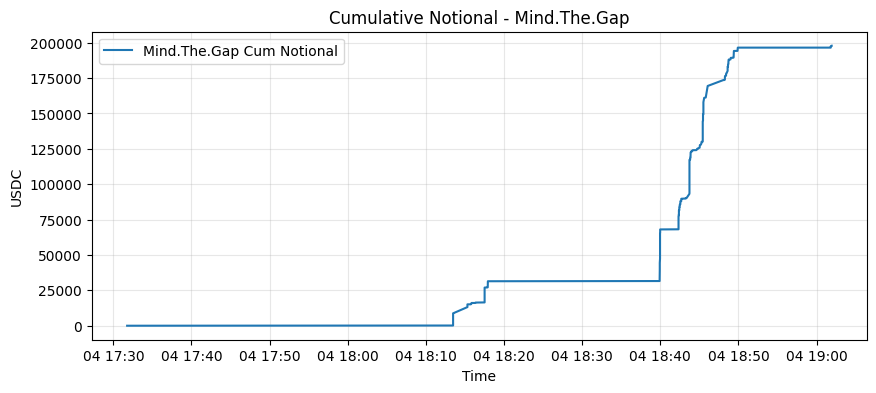

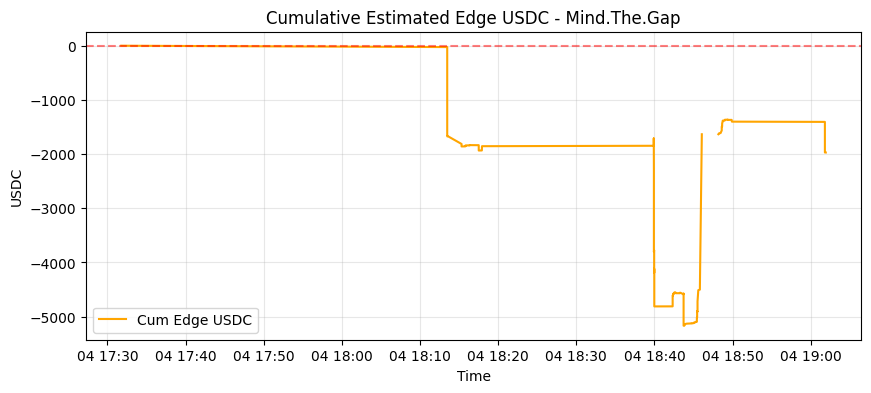

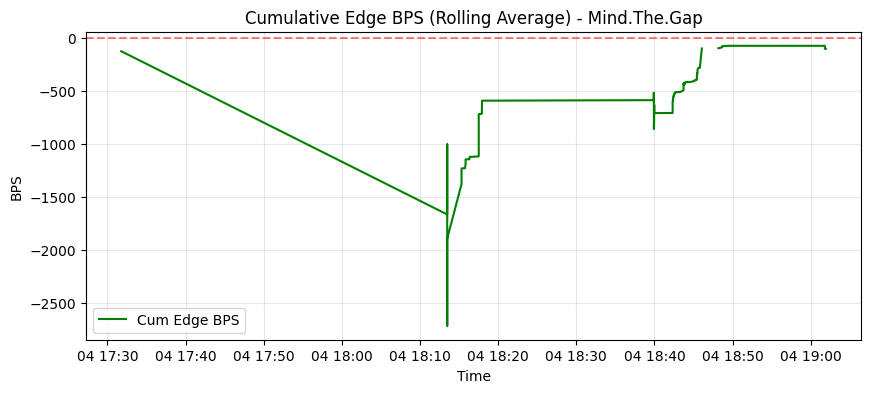

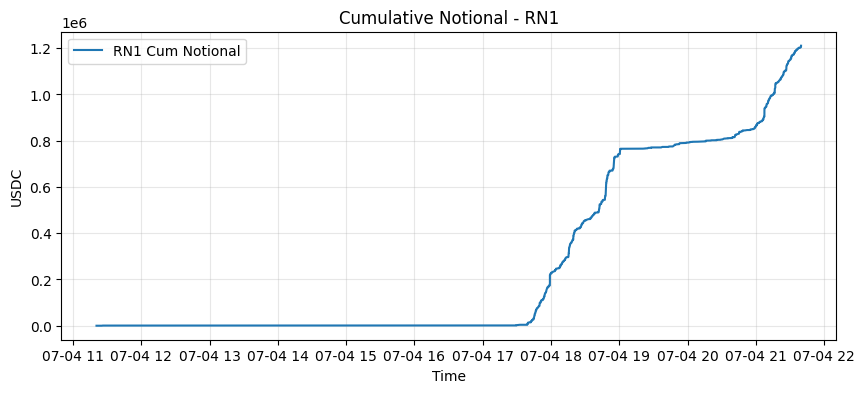

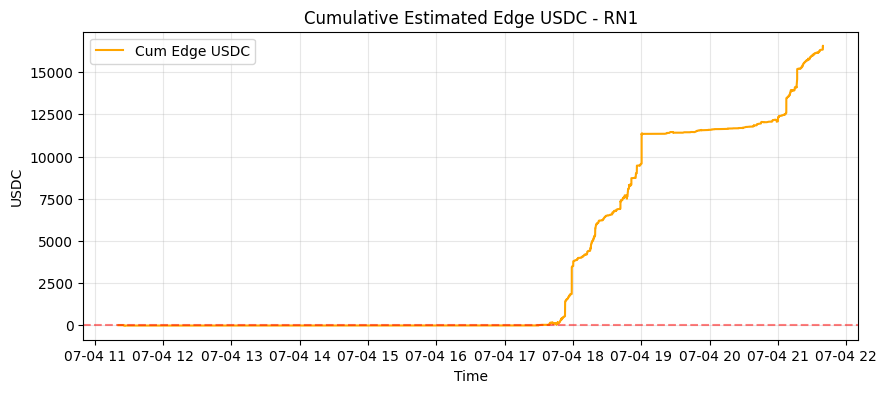

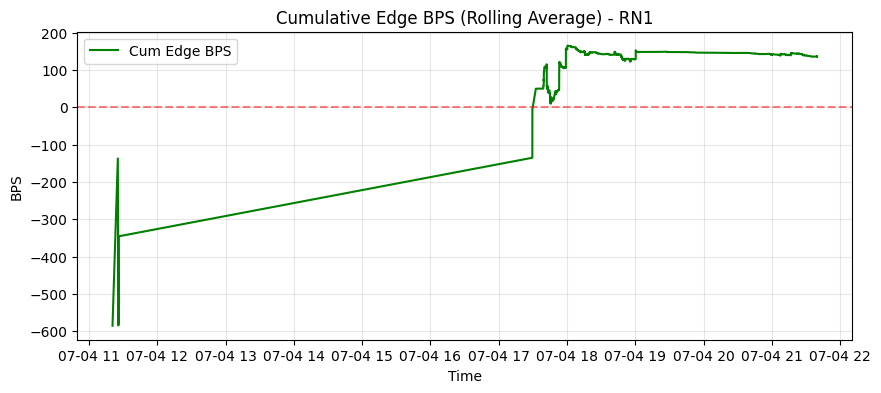

In [20]:
import matplotlib.pyplot as plt

# 1. Prepare time series data
timeseries_df = fills.sort_values(['wallet_label', 'trade_utc']).copy()

# 2. Calculate cumulative metrics per wallet
def calculate_cumulative(group):
    group = group.sort_values('trade_utc')
    group['cum_notional'] = group['notional'].cumsum()
    group['cum_estimated_edge_usdc'] = group['estimated_edge_usdc'].cumsum()
    group['cum_fills'] = range(1, len(group) + 1)
    group['cum_buy_notional'] = (group['notional'] * group['is_buy']).cumsum()
    group['cum_sell_notional'] = (group['notional'] * group['is_sell']).cumsum()
    group['cum_maker_notional'] = (group['notional'] * group['is_maker']).cumsum()
    group['cum_taker_notional'] = (group['notional'] * group['is_taker']).cumsum()
    group['cum_edge_bps'] = (group['cum_estimated_edge_usdc'] / group['cum_notional']) * 10000
    return group

timeseries_df = timeseries_df.groupby('wallet_label', group_keys=False).apply(calculate_cumulative)

# 3. Plotting with matplotlib
wallets = timeseries_df['wallet_label'].unique()

for wallet in wallets:
    data = timeseries_df[timeseries_df['wallet_label'] == wallet]

    # Plot 1: Cumulative Notional
    plt.figure(figsize=(10, 4))
    plt.plot(data['trade_utc'], data['cum_notional'], label=f'{wallet} Cum Notional')
    plt.title(f'Cumulative Notional - {wallet}')
    plt.xlabel('Time')
    plt.ylabel('USDC')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    # Plot 2: Cumulative Estimated Edge USDC
    plt.figure(figsize=(10, 4))
    plt.plot(data['trade_utc'], data['cum_estimated_edge_usdc'], color='orange', label='Cum Edge USDC')
    plt.axhline(0, color='red', linestyle='--', alpha=0.5)
    plt.title(f'Cumulative Estimated Edge USDC - {wallet}')
    plt.xlabel('Time')
    plt.ylabel('USDC')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    # Plot 3: Cumulative Edge BPS
    plt.figure(figsize=(10, 4))
    plt.plot(data['trade_utc'], data['cum_edge_bps'], color='green', label='Cum Edge BPS')
    plt.axhline(0, color='red', linestyle='--', alpha=0.5)
    plt.title(f'Cumulative Edge BPS (Rolling Average) - {wallet}')
    plt.xlabel('Time')
    plt.ylabel('BPS')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

In [21]:
# Define spread buckets
def get_spread_bucket(spread):
    if pd.isna(spread): return 'missing'
    if spread <= 0.005: return '0-0.5c'
    if spread <= 0.01: return '0.5-1c'
    if spread <= 0.02: return '1-2c'
    if spread <= 0.05: return '2-5c'
    if spread <= 0.10: return '5-10c'
    return '>10c'

fills['spread_bucket'] = fills['spread_before'].apply(get_spread_bucket)
spread_order = ['0-0.5c', '0.5-1c', '1-2c', '2-5c', '5-10c', '>10c', 'missing']

# Grouped summary by spread bucket
spread_summary = fills.groupby(['wallet_label', 'role', 'spread_bucket']).agg(
    fills=('wallet', 'size'),
    notional=('notional', 'sum'),
    estimated_edge_usdc=('estimated_edge_usdc', 'sum'),
    positive_edge_count=('estimated_edge_usdc', lambda x: (x > 0).sum()),
    avg_fill_price=('fill_price', 'mean'),
    avg_mid_before=('mid_before', 'mean'),
    avg_age_s=('book_before_age_s', 'mean')
).reset_index()

spread_summary['edge_bps'] = (spread_summary['estimated_edge_usdc'] / spread_summary['notional'] * 10000).fillna(0)
spread_summary['positive_edge_share'] = (spread_summary['positive_edge_count'] / spread_summary['fills'] * 100).fillna(0)

print("--- Spread Bucket Analysis ---")
for wallet in spread_summary['wallet_label'].unique():
    print(f"\nWallet: {wallet}")
    display_df = spread_summary[spread_summary['wallet_label'] == wallet].sort_values(['role', 'spread_bucket'])
    print(display_df.drop(columns=['positive_edge_count']).to_string())


--- Spread Bucket Analysis ---

Wallet: Mind.The.Gap
    wallet_label   role spread_bucket  fills    notional  estimated_edge_usdc  avg_fill_price  avg_mid_before  avg_age_s    edge_bps  positive_edge_share
0   Mind.The.Gap  maker        0-0.5c     17  9182.14722              3.64119         0.98941         0.99162    1.76471     3.96551             94.11765
1   Mind.The.Gap  maker        0.5-1c    176 85170.23876           3392.88311         0.64472         0.64039    1.56250   398.36487             89.20455
2   Mind.The.Gap  maker          1-2c     27  9728.46252            201.78764         0.57185         0.53963    3.48148   207.41987             48.14815
3   Mind.The.Gap  maker          2-5c     32 13626.16758          -1130.06314         0.63281         0.65344    0.87500  -829.33307             68.75000
4   Mind.The.Gap  maker         5-10c     21 11579.61616          -2626.64474         0.50048         0.32595    1.76190 -2268.33489              0.00000
5   Mind.The.Gap  taker

In [22]:
# Define price buckets
def get_price_bucket(price):
    if pd.isna(price): return 'missing'
    if price <= 0.05: return '0.00-0.05'
    if price <= 0.10: return '0.05-0.10'
    if price <= 0.20: return '0.10-0.20'
    if price <= 0.40: return '0.20-0.40'
    if price <= 0.60: return '0.40-0.60'
    if price <= 0.80: return '0.60-0.80'
    if price <= 0.90: return '0.80-0.90'
    if price <= 0.95: return '0.90-0.95'
    return '0.95-1.00'

fills['price_bucket'] = fills['fill_price'].apply(get_price_bucket)

# Grouped summary by price bucket
price_summary = fills.groupby(['wallet_label', 'role', 'price_bucket']).agg(
    fills=('wallet', 'size'),
    notional=('notional', 'sum'),
    estimated_edge_usdc=('estimated_edge_usdc', 'sum'),
    positive_edge_count=('estimated_edge_usdc', lambda x: (x > 0).sum()),
    avg_spread_before=('spread_before', 'mean')
).reset_index()

price_summary['edge_bps'] = (price_summary['estimated_edge_usdc'] / price_summary['notional'] * 10000).fillna(0)
price_summary['positive_edge_share'] = (price_summary['positive_edge_count'] / price_summary['fills'] * 100).fillna(0)

print("--- Price Bucket Analysis ---")
for wallet in price_summary['wallet_label'].unique():
    print(f"\nWallet: {wallet}")
    display_df = price_summary[price_summary['wallet_label'] == wallet].sort_values(['role', 'price_bucket'])
    print(display_df.drop(columns=['positive_edge_count']).to_string())


--- Price Bucket Analysis ---

Wallet: Mind.The.Gap
    wallet_label   role price_bucket  fills    notional  estimated_edge_usdc  avg_spread_before   edge_bps  positive_edge_share
0   Mind.The.Gap  maker    0.05-0.10      1  1837.57400             91.87870            0.01000  500.00000            100.00000
1   Mind.The.Gap  maker    0.10-0.20     10   772.37683             15.51528            0.01300  200.87702             80.00000
2   Mind.The.Gap  maker    0.20-0.40     69 30992.31910           1766.46023            0.02246  569.96710             75.36232
3   Mind.The.Gap  maker    0.40-0.60     34 23157.63119          -1240.05719            0.02382 -535.48534             64.70588
4   Mind.The.Gap  maker    0.60-0.80     47 13488.35838          -1185.12084            0.03170 -878.62496             57.44681
5   Mind.The.Gap  maker    0.80-0.90     88 48661.49268            378.47376            0.01114   77.77685             90.90909
6   Mind.The.Gap  maker    0.90-0.95      1   245.82

In [23]:
# Calculate net-to-gross metrics per token
token_symmetry = fills.groupby(['wallet_label', 'token_id', 'question', 'outcome_label']).agg(
    buy_shares=('fill_size', lambda x: x[fills.loc[x.index, 'side'] == 'buy'].sum()),
    sell_shares=('fill_size', lambda x: x[fills.loc[x.index, 'side'] == 'sell'].sum()),
    buy_notional=('notional', lambda x: x[fills.loc[x.index, 'side'] == 'buy'].sum()),
    sell_notional=('notional', lambda x: x[fills.loc[x.index, 'side'] == 'sell'].sum()),
    total_notional=('notional', 'sum'),
    fills=('wallet', 'size')
).reset_index()

token_symmetry['net_shares'] = token_symmetry['buy_shares'] - token_symmetry['sell_shares']
token_symmetry['gross_shares'] = token_symmetry['buy_shares'] + token_symmetry['sell_shares']
token_symmetry['net_to_gross_ratio'] = (token_symmetry['net_shares'].abs() / token_symmetry['gross_shares']).fillna(0)

# Wallet level aggregation
# Using a safe weighted average function
def safe_weighted_avg(df, val_col, weight_col):
    weights = df[weight_col]
    if weights.sum() == 0: return 0
    return (df[val_col] * weights).sum() / weights.sum()

wallet_symmetry = []
for wallet in fills['wallet_label'].unique():
    w_data = token_symmetry[token_symmetry['wallet_label'] == wallet]
    avg_ntg = safe_weighted_avg(w_data, 'net_to_gross_ratio', 'total_notional')
    pct_bid_ask = (w_data['net_to_gross_ratio'] < 0.99).sum() / len(w_data) * 100
    notional_bid_ask = w_data[w_data['net_to_gross_ratio'] < 0.99]['total_notional'].sum() / w_data['total_notional'].sum() * 100

    wallet_symmetry.append({
        'wallet_label': wallet,
        'weighted_avg_net_to_gross': avg_ntg,
        'pct_tokens_with_two_sides': pct_bid_ask,
        'pct_notional_two_sides': notional_bid_ask
    })

wallet_symmetry_df = pd.DataFrame(wallet_symmetry)

print("--- Inventory Symmetry Analysis ---")
print(wallet_symmetry_df.round(3).to_string())

print("\n--- Top 10 Imbalanced Tokens (High Directional Bias) ---")
print(token_symmetry.sort_values('total_notional', ascending=False).head(10)[['wallet_label', 'question', 'outcome_label', 'net_to_gross_ratio', 'total_notional']].to_string())

--- Inventory Symmetry Analysis ---
   wallet_label  weighted_avg_net_to_gross  pct_tokens_with_two_sides  pct_notional_two_sides
0  Mind.The.Gap                    0.43700                   70.58800                85.19300
1           RN1                    1.00000                    0.00000                 0.00000

--- Top 10 Imbalanced Tokens (High Directional Bias) ---
     wallet_label                                           question     outcome_label  net_to_gross_ratio  total_notional
20            RN1                    Will Morocco win on 2026-07-04?               Yes             1.00000     79905.40868
25            RN1            Canada vs. Morocco: Both Teams to Score                No             1.00000     55345.72489
172           RN1                        Canada vs. Morocco: O/U 1.5              Over             1.00000     53952.86755
34            RN1                     Will Canada win on 2026-07-04?                No             1.00000     53640.49620
123      

In [24]:
# Comparative Matrix: Behavioral Profiles
exploratory_comparison = summary_by_wallet_df[['wallet_label', 'fills', 'notional_total', 'edge_bps', 'unique_questions', 'unique_tokens']].copy()

# Integrate Symmetry and Completion Metrics
symmetry_summary = wallet_symmetry_df.set_index('wallet_label')
completion_summary = completion_candidates.groupby('wallet_label').agg(
    binary_completion_candidates=('question', 'count'),
    theoretical_pair_edge_usdc=('theoretical_pair_edge_usdc', 'sum')
)

exploratory_comparison = exploratory_comparison.set_index('wallet_label').join(symmetry_summary).join(completion_summary).fillna(0)

print("--- Exploratory Strategy Matrix ---")
print(exploratory_comparison.round(3).to_string())

print("\n--- Interpretative Classification ---")
for wallet, row in exploratory_comparison.iterrows():
    if row['weighted_avg_net_to_gross'] > 0.95 and row['binary_completion_candidates'] > 5:
        print(f"{wallet}: Symmetric Market Maker (via Completion Sets)")
    elif row['weighted_avg_net_to_gross'] < 0.60:
        print(f"{wallet}: Directional Accumulator / Hybrid Taker")
    else:
        print(f"{wallet}: Undefined / Mixed Strategy")

--- Exploratory Strategy Matrix ---
              fills  notional_total  edge_bps  unique_questions  unique_tokens  weighted_avg_net_to_gross  pct_tokens_with_two_sides  pct_notional_two_sides  binary_completion_candidates  theoretical_pair_edge_usdc
wallet_label                                                                                                                                                                                                          
RN1            3979   1210480.08000 136.33000                96            162                    1.00000                    0.00000                 0.00000                            34                 12543.83000
Mind.The.Gap    312    197869.82000 -99.60000                10             17                    0.43700                   70.58800                85.19300                             1                     0.00000

--- Interpretative Classification ---
RN1: Symmetric Market Maker (via Completion Sets)
Mind.The.Gap: D

In [25]:
print("--- Key Automated Findings ---")

# 1. Notional Leader
top_notional_wallet = summary_by_wallet_df.iloc[0]['wallet_label']
print(f"- Largest Volume: {top_notional_wallet} ({summary_by_wallet_df.iloc[0]['notional_total']:,.0f} USDC)")

# 2. Edge Leader
top_edge_wallet = summary_by_wallet_df.sort_values('edge_bps', ascending=False).iloc[0]
print(f"- Highest Efficiency: {top_edge_wallet['wallet_label']} ({top_edge_wallet['edge_bps']:.1f} BPS edge)")

# 3. Adverse Selection Check
mtg_wide_spread = spread_summary[(spread_summary['wallet_label'] == 'Mind.The.Gap') & (spread_summary['spread_bucket'] == '5-10c')]['edge_bps'].values[0]
print(f"- Adverse Selection: Mind.The.Gap loses {mtg_wide_spread:.1f} BPS in wider (5-10c) spreads.")

# 4. Strategy Evidence
rn1_pairs = exploratory_comparison.loc['RN1', 'binary_completion_candidates']
print(f"- Basket Building: RN1 shows {rn1_pairs:.0f} potential completion-set candidates, suggesting a market-neutral approach.")

--- Key Automated Findings ---
- Largest Volume: RN1 (1,210,480 USDC)
- Highest Efficiency: RN1 (136.3 BPS edge)
- Adverse Selection: Mind.The.Gap loses -2268.3 BPS in wider (5-10c) spreads.
- Basket Building: RN1 shows 34 potential completion-set candidates, suggesting a market-neutral approach.


# Interpretación de Resultados: Perfiles de Ejecución y Edge Estadístico

### 1. Qué sí sabemos (Evidencia Fuerte)
* **Disparidad de Eficiencia:** La wallet **RN1** opera con una eficiencia significativamente mayor (+136.3 BPS de edge promedio) comparada con **Mind.The.Gap** (-99.6 BPS).
* **Sensibilidad al Spread:** Mind.The.Gap sufre una degradación severa en su edge cuando el spread se ensancha (perdiendo más de 2200 BPS en buckets de 5-10c), lo que indica una ejecución vulnerable a la selección adversa.
* **Calidad de Entrada:** Es fundamental notar que el `estimated_edge_usdc` utilizado aquí mide la **calidad de la entrada** contra el `mid_before` en el momento del fill. **No representa el PnL final**, ya que no considera el movimiento del precio posterior ni el cierre de la posición.
* **Limitación de Roles:** Los registros marcados como `unenriched` no deben clasificarse prematuramente como maker o taker; representan ejecuciones donde la atribución de rol aún no es definitiva.

### 2. Qué parece sugerir RN1 (Evidencia Moderada)
* **Estrategia Neutral:** La detección de **34 candidatos a completion-sets** sugiere que RN1 no apuesta a una dirección, sino que busca capturar el spread completando ambos lados del evento (Yes/No).
* **Market Making Simétrico:** El hecho de que su `weighted_avg_net_to_gross` sea cercano a 1.0 en tokens individuales pero presente combinaciones de precios suma < 1.0 a nivel de pregunta, sugiere que su "inventario" se equilibra mediante la compra de todas las ramas del contrato.
* **Aproximación de Pares:** Los `completion-set candidates` identificados son aproximaciones basadas en precios promedio. La confirmación total requiere un análisis *fill-by-fill* para asegurar que las cantidades se emparejaron en ventanas temporales coherentes.

### 3. Qué parece sugerir Mind.The.Gap (Evidencia Moderada)
* **Acumulador Direccional:** A diferencia de RN1, esta wallet muestra un `net-to-gross` de 0.43, lo que indica una tendencia a acumular posiciones en una sola dirección en lugar de arbitrar el spread entre outcomes.
* **Ejecución Híbrida:** Su comportamiento sugiere que actúa como un *Taker* agresivo o un *Maker* pasivo que es frecuentemente "atropellado" por el flujo informado, especialmente en mercados de baja liquidez.

### 4. Qué no se puede concluir todavía (Evidencia Insuficiente)
* **Rentabilidad Real:** Sin la data de los cierres de posición o el PnL realizado, no podemos afirmar que RN1 sea "rentable" en términos netos, solo que entra al mercado en condiciones más favorables.
* **Causalidad del Edge:** Las correlaciones Spearman muestran asociaciones (ej. relación entre tamaño de fill y edge), pero no prueban que un factor cause el otro.

### 5. Próximos Pasos
* **Análisis Lead-Lag:** Determinar si los trades de estas wallets preceden a los movimientos del mid-price (indicando Alpha).
* **Estudio de Decaimiento:** Evaluar cuánto tiempo persiste el edge capturado después de la ejecución.
* **Validación de Pares:** Refinar el análisis de RN1 para identificar coincidencias exactas de tiempo y tamaño en sus completion-sets.

In [27]:
import os

# Create outputs directory
output_dir = 'outputs'
os.makedirs(output_dir, exist_ok=True)

# Export dataframes to CSV
exports = {
    'summary_wallets.csv': summary_by_wallet_df,
    'summary_common_window.csv': summary_common_window_df,
    'summary_role_side.csv': exploratory_comparison,
    'top_questions.csv': grouped_by_question,
    'top_tokens.csv': grouped_by_outcome,
    'binary_questions.csv': question_level_summary,
    'completion_candidates.csv': completion_candidates,
    'token_inventory_symmetry.csv': token_symmetry,
    'exploratory_comparison_matrix.csv': exploratory_comparison
}

print("--- Exporting Results ---")
for filename, df in exports.items():
    path = os.path.join(output_dir, filename)
    df.to_csv(path, index=True)
    print(f"Exported: {path}")

--- Exporting Results ---
Exported: outputs/summary_wallets.csv
Exported: outputs/summary_common_window.csv
Exported: outputs/summary_role_side.csv
Exported: outputs/top_questions.csv
Exported: outputs/top_tokens.csv
Exported: outputs/binary_questions.csv
Exported: outputs/completion_candidates.csv
Exported: outputs/token_inventory_symmetry.csv
Exported: outputs/exploratory_comparison_matrix.csv


In [28]:
# 1. Prepare correlation base dataframe
corr_base = fills[fills['valid_before_book'] == True].copy()

# 2. Define numerical columns
num_cols = [
    'fill_price', 'fill_size', 'notional', 'book_before_age_s',
    'best_bid_before', 'best_ask_before', 'spread_before', 'mid_before',
    'edge_vs_mid_before', 'estimated_edge_usdc'
]

# 3. Add binary indicators
corr_base['is_buy_num'] = corr_base['is_buy'].astype(int)
corr_base['is_sell_num'] = corr_base['is_sell'].astype(int)
corr_base['is_maker_num'] = corr_base['is_maker'].astype(int)
corr_base['is_taker_num'] = corr_base['is_taker'].astype(int)
corr_base['is_unenriched_num'] = corr_base['is_unenriched'].astype(int)
corr_base['strict_before_book_num'] = corr_base['strict_before_book'].astype(int)

# 4. Add derived variables
corr_base['edge_bps_fill'] = (corr_base['estimated_edge_usdc'] / corr_base['notional'] * 10000)
corr_base['spread_bps'] = corr_base['spread_before'] * 10000
corr_base['fill_vs_bid'] = corr_base['fill_price'] - corr_base['best_bid_before']
corr_base['ask_vs_fill'] = corr_base['best_ask_before'] - corr_base['fill_price']
corr_base['abs_mid_distance'] = abs(corr_base['fill_price'] - corr_base['mid_before'])

# Cleanup inf/nan
initial_shape = corr_base.shape
# Focus on columns used for correlation
analysis_cols = num_cols + ['is_buy_num', 'is_sell_num', 'is_maker_num', 'is_taker_num', 'is_unenriched_num', 'strict_before_book_num', 'edge_bps_fill', 'spread_bps', 'fill_vs_bid', 'ask_vs_fill', 'abs_mid_distance']
corr_base = corr_base.replace([np.inf, -np.inf], np.nan).dropna(subset=['edge_bps_fill'] + num_cols)

print(f"Shape before: {initial_shape}")
print(f"Shape after cleanup: {corr_base.shape}")
print("\nNull counts in analysis columns:")
print(corr_base[analysis_cols].isnull().sum())

Shape before: (4291, 53)
Shape after cleanup: (4284, 53)

Null counts in analysis columns:
fill_price                0
fill_size                 0
notional                  0
book_before_age_s         0
best_bid_before           0
best_ask_before           0
spread_before             0
mid_before                0
edge_vs_mid_before        0
estimated_edge_usdc       0
is_buy_num                0
is_sell_num               0
is_maker_num              0
is_taker_num              0
is_unenriched_num         0
strict_before_book_num    0
edge_bps_fill             0
spread_bps                0
fill_vs_bid               0
ask_vs_fill               0
abs_mid_distance          0
dtype: int64


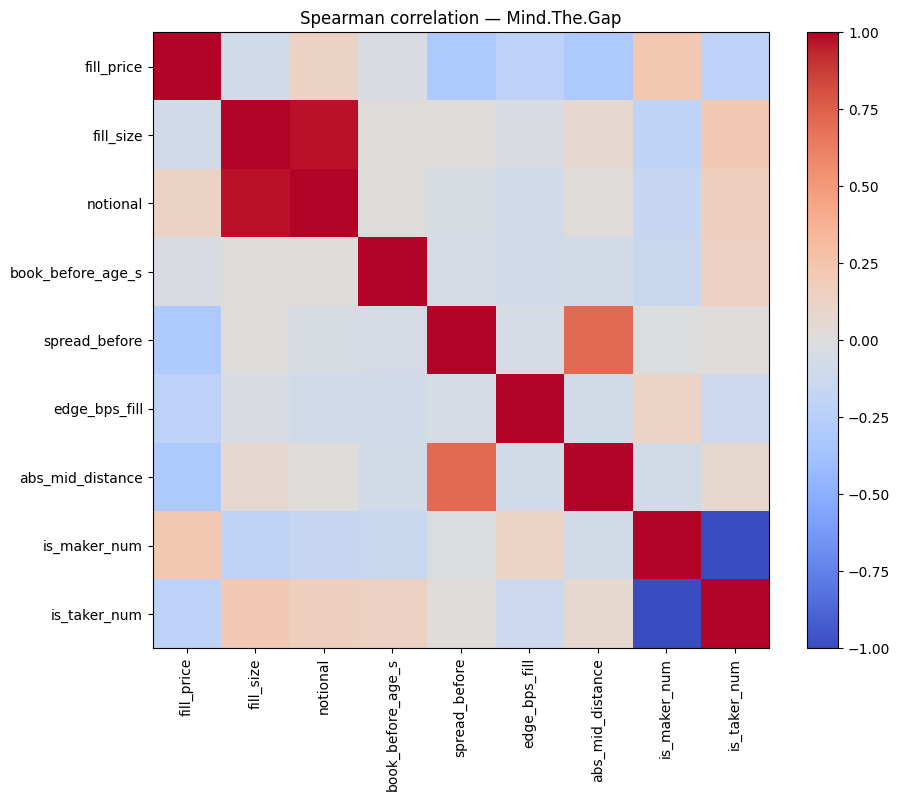

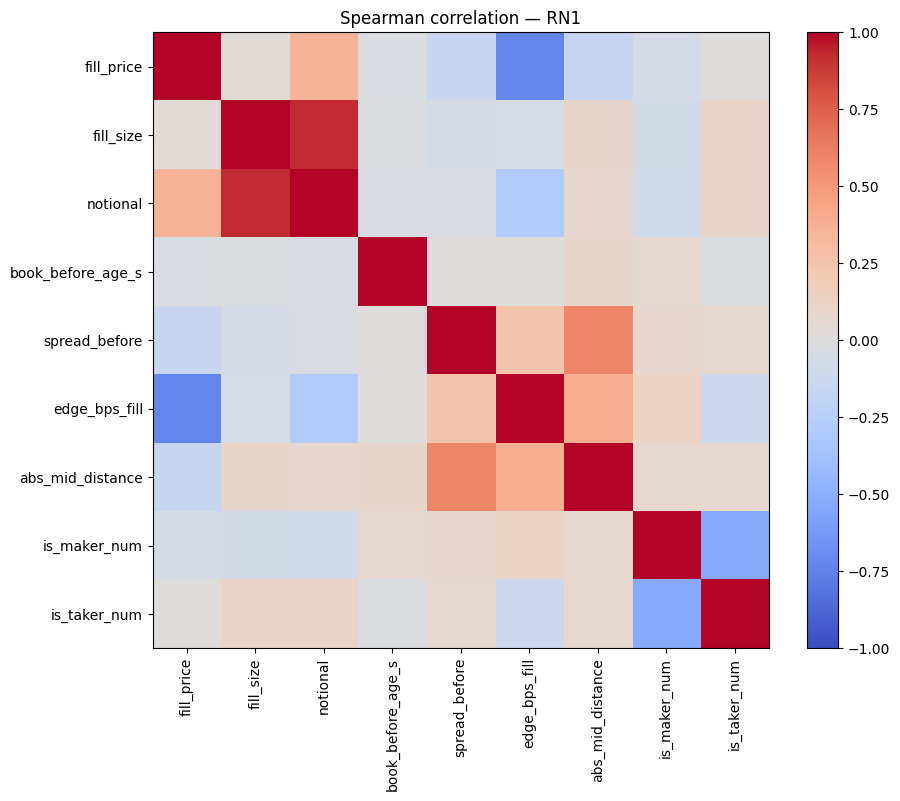

In [29]:
for wallet in corr_base['wallet_label'].unique():
    df_wallet = corr_base[corr_base['wallet_label'] == wallet]

    # Select subset of columns for the heatmap
    plot_cols = [
        'fill_price', 'fill_size', 'notional', 'book_before_age_s',
        'spread_before', 'edge_bps_fill', 'abs_mid_distance',
        'is_maker_num', 'is_taker_num'
    ]

    corr_matrix = df_wallet[plot_cols].corr(method='spearman')

    plt.figure(figsize=(10, 8))
    im = plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
    plt.colorbar(im)

    plt.xticks(range(len(plot_cols)), plot_cols, rotation=90)
    plt.yticks(range(len(plot_cols)), plot_cols)
    plt.title(f"Spearman correlation — {wallet}")
    plt.show()

In [30]:
results_corr = []
numeric_vars = ['fill_price', 'fill_size', 'notional', 'book_before_age_s', 'spread_before', 'mid_before', 'fill_vs_bid', 'ask_vs_fill', 'abs_mid_distance']

for (wallet, role), group in corr_base.groupby(['wallet_label', 'role']):
    if len(group) >= 30:
        for var in numeric_vars:
            c_bps = group[var].corr(group['edge_bps_fill'], method='spearman')
            c_usdc = group[var].corr(group['estimated_edge_usdc'], method='spearman')
            results_corr.append({
                'wallet': wallet, 'role': role, 'variable': var,
                'corr_edge_bps': c_bps, 'corr_edge_usdc': c_usdc, 'n': len(group)
            })

corr_detailed_df = pd.DataFrame(results_corr).sort_values(['wallet', 'role', 'corr_edge_bps'], ascending=[True, True, False])
print("--- Detailed Spearman Correlations by Wallet & Role ---")
print(corr_detailed_df.to_string(index=False))

--- Detailed Spearman Correlations by Wallet & Role ---
      wallet       role          variable  corr_edge_bps  corr_edge_usdc    n
Mind.The.Gap      maker       ask_vs_fill        0.47729         0.54187  273
Mind.The.Gap      maker book_before_age_s        0.02769         0.02763  273
Mind.The.Gap      maker         fill_size        0.01055         0.45896  273
Mind.The.Gap      maker     spread_before       -0.04535        -0.20473  273
Mind.The.Gap      maker          notional       -0.05991         0.44761  273
Mind.The.Gap      maker  abs_mid_distance       -0.06716        -0.18070  273
Mind.The.Gap      maker        mid_before       -0.16045         0.14989  273
Mind.The.Gap      maker        fill_price       -0.34343         0.01328  273
Mind.The.Gap      maker       fill_vs_bid       -0.44642        -0.54265  273
Mind.The.Gap      taker       ask_vs_fill        0.61556         0.40832   38
Mind.The.Gap      taker        mid_before        0.46193         0.25921   38
Mind.The

In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

features = ['fill_price', 'fill_size', 'notional', 'book_before_age_s', 'spread_before', 'mid_before', 'fill_vs_bid', 'ask_vs_fill', 'abs_mid_distance', 'is_buy_num', 'is_sell_num', 'is_maker_num', 'is_taker_num', 'strict_before_book_num']

print("--- Exploratory Linear Regression (Standardized Coefficients) ---")
for wallet in corr_base['wallet_label'].unique():
    df_w = corr_base[corr_base['wallet_label'] == wallet].dropna(subset=features + ['edge_bps_fill'])
    X = StandardScaler().fit_transform(df_w[features])
    y = df_w['edge_bps_fill']

    model = LinearRegression().fit(X, y)
    coefs = pd.Series(model.coef_, index=features).abs().sort_values(ascending=False)

    print(f"\nWallet: {wallet} | R^2: {model.score(X, y):.4f}")
    print("Top Coefficients (Impact on Edge BPS):")
    print(coefs.head(5))

--- Exploratory Linear Regression (Standardized Coefficients) ---

Wallet: Mind.The.Gap | R^2: 0.8970
Top Coefficients (Impact on Edge BPS):
ask_vs_fill         814.39324
fill_vs_bid         775.12255
mid_before          153.86150
abs_mid_distance    152.06067
book_before_age_s   108.44558
dtype: float64

Wallet: RN1 | R^2: 0.2361
Top Coefficients (Impact on Edge BPS):
abs_mid_distance   312.17220
fill_vs_bid        281.73377
fill_size          233.52536
notional           225.62188
ask_vs_fill        145.63784
dtype: float64


--- Distribution Comparison Table ---
                                count       mean        std         min  \
wallet       variable                                                     
RN1          fill_price    3973.00000    0.51361    0.29586     0.00100   
             fill_size     3973.00000  616.81386 1491.01584     0.01000   
             notional      3973.00000  303.46778  882.58948     0.00200   
             spread_before 3973.00000    0.01085    0.00921     0.00100   
             edge_bps_fill 3973.00000  312.70381 1538.20791 -3108.10816   
Mind.The.Gap fill_price     311.00000    0.62670    0.26397     0.10000   
             fill_size      311.00000 1278.89846 3592.25945     1.85000   
             notional       311.00000  622.85277 1469.66669     0.72000   
             spread_before  311.00000    0.01888    0.01985     0.00100   
             edge_bps_fill  311.00000 -243.21567 1679.33575 -8396.22642   

                                   10%       25%       50%   

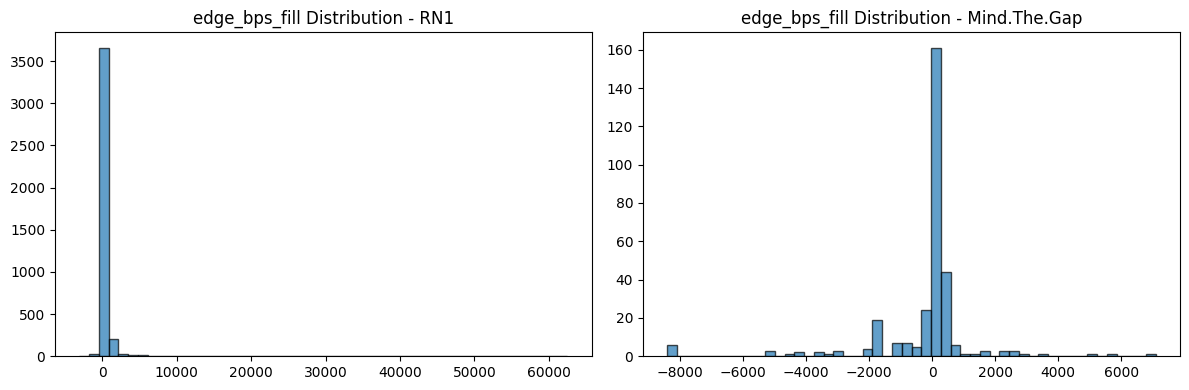

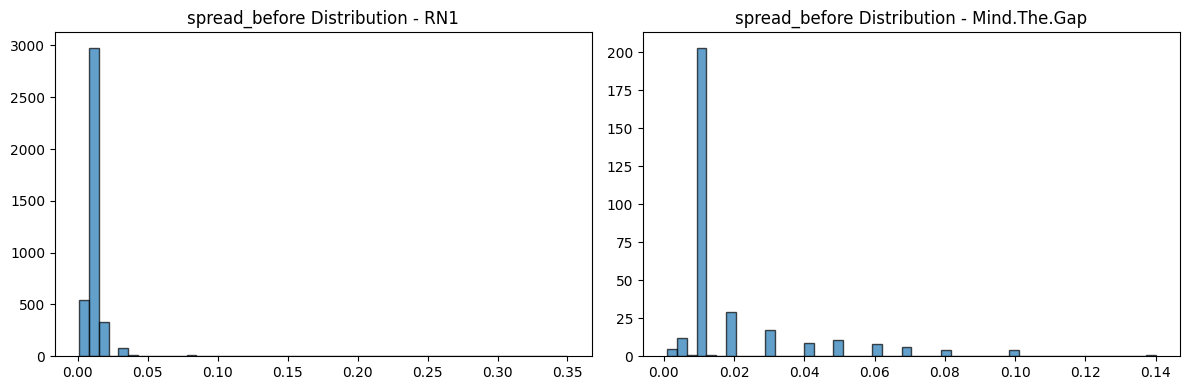

In [32]:
vars_to_compare = ['fill_price', 'fill_size', 'notional', 'spread_before', 'edge_bps_fill']
stats_list = []

for wallet in ['RN1', 'Mind.The.Gap']:
    df_w = corr_base[corr_base['wallet_label'] == wallet]
    for v in vars_to_compare:
        desc = df_w[v].describe(percentiles=[.1, .25, .75, .9, .95])
        desc['wallet'] = wallet
        desc['variable'] = v
        stats_list.append(desc)

comparison_table = pd.concat(stats_list, axis=1).T.set_index(['wallet', 'variable'])
print("--- Distribution Comparison Table ---")
print(comparison_table)

for v in ['edge_bps_fill', 'spread_before']:
    plt.figure(figsize=(12, 4))
    for i, w in enumerate(['RN1', 'Mind.The.Gap'], 1):
        plt.subplot(1, 2, i)
        plt.hist(corr_base[corr_base['wallet_label'] == w][v], bins=50, alpha=0.7, edgecolor='black')
        plt.title(f"{v} Distribution - {w}")
    plt.tight_layout()
    plt.show()

In [33]:
# Identify outliers in edge_bps_fill and estimated_edge_usdc
outliers_summary = []

for wallet in corr_base['wallet_label'].unique():
    df_w = corr_base[corr_base['wallet_label'] == wallet]

    outliers_summary.append({
        'wallet': wallet,
        'max_edge_bps': df_w['edge_bps_fill'].max(),
        'min_edge_bps': df_w['edge_bps_fill'].min(),
        'max_edge_usdc': df_w['estimated_edge_usdc'].max(),
        'min_edge_usdc': df_w['estimated_edge_usdc'].min()
    })

print("--- Outlier Summary Statistics ---")
print(pd.DataFrame(outliers_summary).round(2))

# Show the most extreme positive outlier for each wallet to inspect quality
print("\n--- Top Outlier Details (Max Edge BPS) ---")
cols_to_show = ['trade_utc', 'question', 'outcome_label', 'fill_price', 'mid_before', 'edge_bps_fill', 'estimated_edge_usdc']
for wallet in corr_base['wallet_label'].unique():
    top_row = corr_base[corr_base['wallet_label'] == wallet].sort_values('edge_bps_fill', ascending=False).head(1)
    print(f"\nWallet: {wallet}")
    print(top_row[cols_to_show].to_string(index=False))

--- Outlier Summary Statistics ---
         wallet  max_edge_bps  min_edge_bps  max_edge_usdc  min_edge_usdc
0  Mind.The.Gap    7086.30000   -8396.23000     2867.41000    -1019.33000
1           RN1   62500.00000   -3108.11000      664.84000     -182.29000

--- Top Outlier Details (Max Edge BPS) ---

Wallet: Mind.The.Gap
          trade_utc               question outcome_label  fill_price  mid_before  edge_bps_fill  estimated_edge_usdc
2026-07-04 18:45:31 Spread: Morocco (-1.5)       Morocco     0.38333     0.66000     7086.30090              8.30000

Wallet: RN1
          trade_utc                           question outcome_label  fill_price  mid_before  edge_bps_fill  estimated_edge_usdc
2026-07-04 17:53:05 Exact Score: Canada 1 - 1 Morocco?           Yes     0.02000     0.14500    62500.00000            510.90625


In [34]:
# Winsorized analysis to check robustness
winsor_results = []

for wallet in corr_base['wallet_label'].unique():
    df_w = corr_base[corr_base['wallet_label'] == wallet].copy()

    # Calculate 1st and 99th percentiles for edge_bps_fill
    p1 = df_w['edge_bps_fill'].quantile(0.01)
    p99 = df_w['edge_bps_fill'].quantile(0.99)

    # Apply winsorization (clipping)
    df_w['edge_bps_winsor'] = df_w['edge_bps_fill'].clip(lower=p1, upper=p99)
    df_w['edge_usdc_winsor'] = (df_w['edge_bps_winsor'] / 10000) * df_w['notional']

    # Aggregate comparisons
    orig_agg_bps = (df_w['estimated_edge_usdc'].sum() / df_w['notional'].sum()) * 10000
    winsor_agg_bps = (df_w['edge_usdc_winsor'].sum() / df_w['notional'].sum()) * 10000

    winsor_results.append({
        'wallet': wallet,
        'original_agg_bps': orig_agg_bps,
        'winsorized_agg_bps': winsor_agg_bps,
        'impact_bps': orig_agg_bps - winsor_agg_bps,
        'p1_bps': p1,
        'p99_bps': p99
    })

print("--- Winsorization Impact Analysis (1% and 99% Tails Capped) ---")
print(pd.DataFrame(winsor_results).round(2).to_string(index=False))

--- Winsorization Impact Analysis (1% and 99% Tails Capped) ---
      wallet  original_agg_bps  winsorized_agg_bps  impact_bps      p1_bps    p99_bps
Mind.The.Gap        -101.74000          -105.39000     3.65000 -8396.23000 3444.44000
         RN1         136.87000           123.59000    13.28000  -384.62000 4000.00000


In [37]:
# Lead-Lag Analysis: Does the trade predict mid-price movement (Alpha)?
def calculate_alpha(df):
    # Calculate drift from mid_before to mid_after
    df['mid_drift_bps'] = ((df['mid_after'] - df['mid_before']) / df['mid_before'] * 10000)

    # Alpha is positive if the price moves in the direction of our trade (Buy -> Price Up, Sell -> Price Down)
    df['alpha_bps'] = np.where(df['side'] == 'buy', df['mid_drift_bps'], -df['mid_drift_bps'])

    return df.groupby(['wallet_label', 'role']).agg(
        fills=('wallet', 'size'),
        avg_alpha_bps=('alpha_bps', 'mean'),
        median_alpha_bps=('alpha_bps', 'median'),
        std_alpha_bps=('alpha_bps', 'std')
    ).round(2)

print("--- Alpha Analysis: Price Drift following execution ---")
print(calculate_alpha(fills))

--- Alpha Analysis: Price Drift following execution ---
                         fills  avg_alpha_bps  median_alpha_bps  std_alpha_bps
wallet_label role                                                             
Mind.The.Gap maker         273     1828.77000           0.00000    13586.23000
             taker          39     3718.86000           0.00000    16054.06000
RN1          maker        3707      -53.52000           0.00000      425.82000
             taker          79      -43.35000           0.00000      515.66000
             unenriched    193      -22.46000           0.00000      369.20000


In [41]:
# Ensure edge_bps_fill is calculated in the main dataframe
fills['edge_bps_fill'] = np.where(
    fills['notional'] > 0,
    (fills['estimated_edge_usdc'] / fills['notional'] * 10000),
    0
)

# Edge Decay Study: Comparing Edge vs Mid-Before vs Edge vs Mid-After
decay_df = fills.dropna(subset=['mid_after']).copy()

# Calculate edge relative to mid_after
decay_df['edge_after_bps'] = np.where(
    decay_df['side'] == 'buy',
    (decay_df['mid_after'] - decay_df['fill_price']) / decay_df['fill_price'] * 10000,
    (decay_df['fill_price'] - decay_df['mid_after']) / decay_df['fill_price'] * 10000
)

decay_summary = decay_df.groupby('wallet_label').agg(
    initial_avg_edge_bps=('edge_bps_fill', 'mean'),
    post_trade_avg_edge_bps=('edge_after_bps', 'mean')
).round(2)

decay_summary['decay_bps'] = decay_summary['initial_avg_edge_bps'] - decay_summary['post_trade_avg_edge_bps']

print("--- Edge Decay Analysis (Immediate Persistence) ---")
print(decay_summary)

--- Edge Decay Analysis (Immediate Persistence) ---
              initial_avg_edge_bps  post_trade_avg_edge_bps  decay_bps
wallet_label                                                          
Mind.The.Gap            -247.19000                 -0.53000 -246.66000
RN1                      316.65000                245.17000   71.48000


In [35]:
# Lead-Lag Analysis: Does entry edge predict future mid-price movement (Alpha)?
def calculate_lead_lag(df, window_seconds=[10, 30, 60, 300]):
    # This requires merging the fills with subsequent book updates which we don't have in raw form,
    # but we can approximate if 'mid_after' or future fills exist.
    # Since we have 'mid_after' (book after trade), let's use that as a proxy for a short-term lead.

    df['mid_drift_bps'] = ((df['mid_after'] - df['mid_before']) / df['mid_before'] * 10000)
    # Directional Alpha: If I buy, does price go up? If I sell, does it go down?
    df['alpha_bps'] = np.where(df['side'] == 'buy', df['mid_drift_bps'], -df['mid_drift_bps'])

    alpha_summary = df.groupby(['wallet_label', 'role']).agg(
        fills=('wallet', 'size'),
        avg_alpha_bps=('alpha_bps', 'mean'),
        median_alpha_bps=('alpha_bps', 'median'),
        std_alpha_bps=('alpha_bps', 'std')
    ).round(2)

    return alpha_summary

print("--- Alpha Analysis (Mid-Price Drift after Trade) ---")
print(calculate_lead_lag(fills))

--- Alpha Analysis (Mid-Price Drift after Trade) ---
                         fills  avg_alpha_bps  median_alpha_bps  std_alpha_bps
wallet_label role                                                             
Mind.The.Gap maker         273     1828.77000           0.00000    13586.23000
             taker          39     3718.86000           0.00000    16054.06000
RN1          maker        3707      -53.52000           0.00000      425.82000
             taker          79      -43.35000           0.00000      515.66000
             unenriched    193      -22.46000           0.00000      369.20000


In [40]:
# Edge Decay Study: Comparing Edge vs Mid-Before vs Edge vs Mid-After
decay_df = fills.dropna(subset=['mid_after']).copy()
decay_df['edge_after_bps'] = np.where(
    decay_df['side'] == 'buy',
    (decay_df['mid_after'] - decay_df['fill_price']) / decay_df['fill_price'] * 10000,
    (decay_df['fill_price'] - decay_df['mid_after']) / decay_df['fill_price'] * 10000
)

decay_comparison = decay_df.groupby('wallet_label').agg(
    initial_edge_bps=('edge_bps_fill', 'mean'),
    post_trade_edge_bps=('edge_after_bps', 'mean')
).round(2)

decay_comparison['decay_pct'] = ((decay_comparison['initial_edge_bps'] - decay_comparison['post_trade_edge_bps']) / decay_comparison['initial_edge_bps'] * 100)

print("--- Edge Decay Analysis ---")
print(decay_comparison)

--- Edge Decay Analysis ---
              initial_edge_bps  post_trade_edge_bps  decay_pct
wallet_label                                                  
Mind.The.Gap        -247.19000             -0.53000   99.78559
RN1                  316.65000            245.17000   22.57382


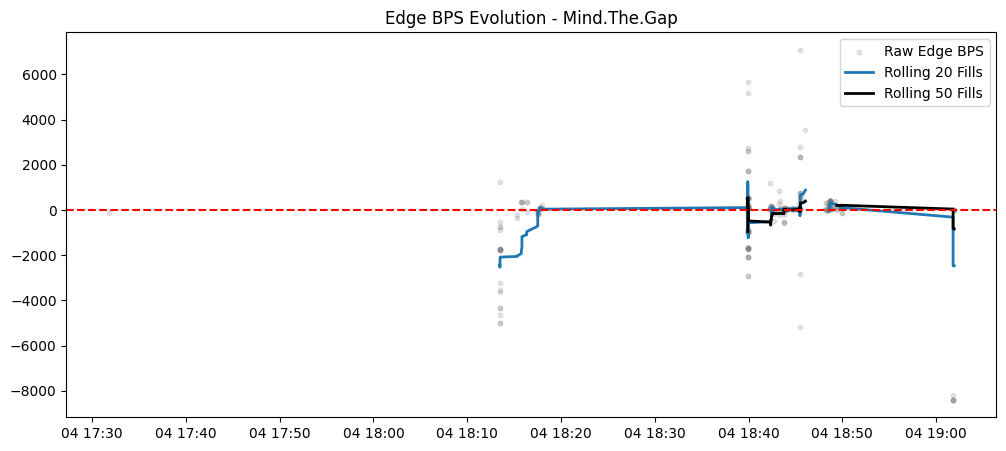


--- Autocorrelation of Edge BPS: Mind.The.Gap ---
Lag 1: 0.5796
Lag 2: 0.4429
Lag 5: 0.3385
Lag 10: 0.0901
Lag 20: -0.0624


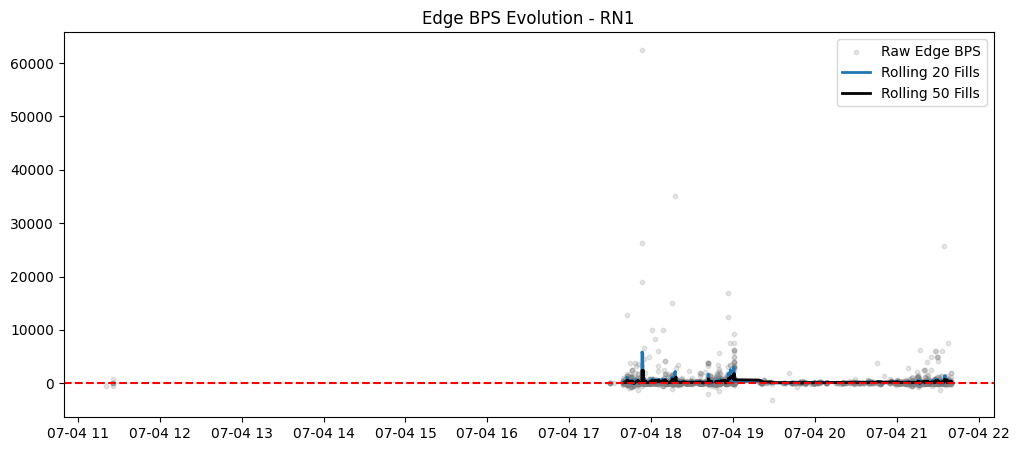


--- Autocorrelation of Edge BPS: RN1 ---
Lag 1: 0.3027
Lag 2: 0.1755
Lag 5: 0.0254
Lag 10: 0.0008
Lag 20: -0.0016


In [42]:
for wallet in fills['wallet_label'].unique():
    df_w = fills[fills['wallet_label'] == wallet].sort_values('trade_utc').copy()

    # Calculations
    df_w['edge_bps_fill'] = (df_w['estimated_edge_usdc'] / df_w['notional'] * 10000)
    df_w['rolling_edge_bps_20'] = df_w['edge_bps_fill'].rolling(20).mean()
    df_w['rolling_edge_bps_50'] = df_w['edge_bps_fill'].rolling(50).mean()
    df_w['rolling_notional_20'] = df_w['notional'].rolling(20).mean()
    df_w['rolling_spread_20'] = df_w['spread_before'].rolling(20).mean()

    # Plotting
    plt.figure(figsize=(12, 5))
    plt.scatter(df_w['trade_utc'], df_w['edge_bps_fill'], alpha=0.2, s=10, label='Raw Edge BPS', color='gray')
    plt.plot(df_w['trade_utc'], df_w['rolling_edge_bps_20'], label='Rolling 20 Fills', linewidth=2)
    plt.plot(df_w['trade_utc'], df_w['rolling_edge_bps_50'], label='Rolling 50 Fills', linewidth=2, color='black')
    plt.axhline(0, color='red', linestyle='--')
    plt.title(f"Edge BPS Evolution - {wallet}")
    plt.legend()
    plt.show()

    # Autocorrelation
    print(f"\n--- Autocorrelation of Edge BPS: {wallet} ---")
    for lag in [1, 2, 5, 10, 20]:
        ac = df_w['edge_bps_fill'].autocorr(lag=lag)
        print(f"Lag {lag}: {ac:.4f}")

In [49]:
# Fix: Parameter name for KMeans is n_clusters
fills['is_buy_num'] = fills['is_buy'].astype(int)
fills['is_maker_num'] = fills['is_maker'].astype(int)
fills['is_taker_num'] = fills['is_taker'].astype(int)
fills['abs_mid_distance'] = abs(fills['fill_price'] - fills['mid_before'])
fills['edge_bps_fill'] = (fills['estimated_edge_usdc'] / fills['notional'] * 10000)

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Prepare features
cluster_data = fills[fills['valid_before_book'] == True].copy()
features_list = ['fill_price', 'spread_before', 'book_before_age_s', 'edge_bps_fill', 'abs_mid_distance', 'is_buy_num', 'is_maker_num', 'is_taker_num']
cluster_data['log_notional'] = np.log1p(cluster_data['notional'])
final_features = features_list + ['log_notional']

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_data[final_features].fillna(0))

# KMeans loops - Corrected parameter n_clusters
for k in [3, 4, 5]:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto').fit(X_scaled)
    cluster_data[f'cluster_{k}'] = kmeans.labels_

# Summary of execution clusters (using k=4)
cluster_summary = cluster_data.groupby(['wallet_label', 'cluster_4']).agg(
    fills=('wallet', 'size'),
    avg_notional=('notional', 'mean'),
    avg_edge_bps=('edge_bps_fill', 'mean'),
    maker_share=('is_maker', 'mean')
).round(2)

print("--- Execution Clusters (k=4) ---")
print(cluster_summary)
cluster_data.to_csv('outputs/execution_clusters.csv')

--- Execution Clusters (k=4) ---
                        fills  avg_notional  avg_edge_bps  maker_share
wallet_label cluster_4                                                
Mind.The.Gap 0            177     682.04000    -143.90000      1.00000
             1             90      87.61000     -17.10000      1.00000
             2              9      79.49000   -4787.39000      0.67000
             3             36    1904.12000    -158.38000      0.00000
RN1          0           1969     550.67000      82.09000      0.94000
             1           1929      33.27000     553.53000      0.96000
             2              3      56.97000    3441.58000      0.33000
             3             78     793.03000      40.42000      0.00000


Explained Variance: [0.19702823 0.1693369 ]


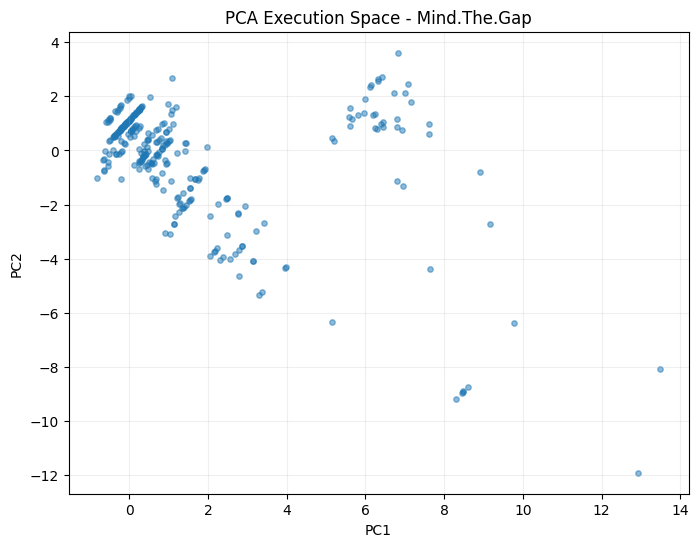

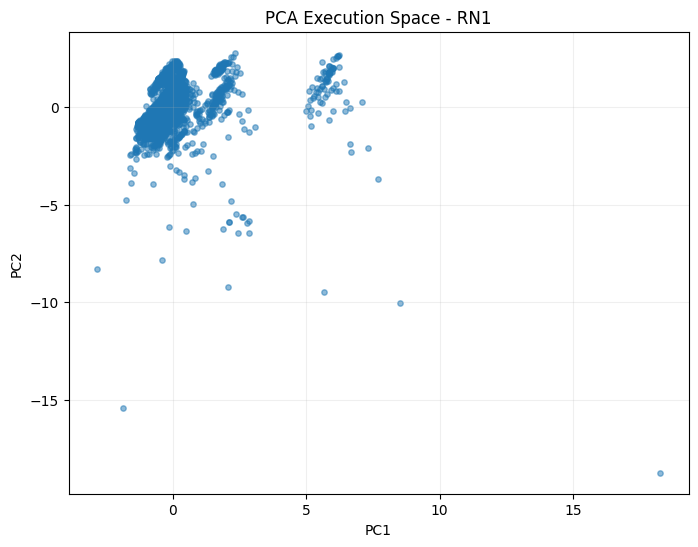


--- PCA Loadings ---
                      PC1     PC2
is_taker_num      0.60020 0.06536
is_maker_num      0.55508 0.13395
abs_mid_distance  0.34481 0.43249
spread_before     0.32419 0.50179
log_notional      0.26253 0.40388
is_buy_num        0.13296 0.03539
fill_price        0.11226 0.51459
edge_bps_fill     0.07682 0.30997
book_before_age_s 0.05045 0.11695


In [47]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)
cluster_data['PC1'] = pcs[:, 0]
cluster_data['PC2'] = pcs[:, 1]

print(f"Explained Variance: {pca.explained_variance_ratio_}")

for wallet in cluster_data['wallet_label'].unique():
    plt.figure(figsize=(8, 6))
    subset = cluster_data[cluster_data['wallet_label'] == wallet]
    plt.scatter(subset['PC1'], subset['PC2'], alpha=0.5, s=15)
    plt.title(f"PCA Execution Space - {wallet}")
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.grid(True, alpha=0.2)
    plt.show()

# Loadings
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=final_features)
print("\n--- PCA Loadings ---")
print(loadings.abs().sort_values('PC1', ascending=False))

In [50]:
# Fix: Explicitly name indices to avoid 'cannot insert question' error
fills['minute_bucket'] = fills['trade_utc'].dt.floor('min')

for wallet in fills['wallet_label'].unique():
    w_fills = fills[fills['wallet_label'] == wallet]
    pivot_exposure = w_fills.pivot_table(
        index='minute_bucket',
        columns='question',
        values='signed_shares',
        aggfunc='sum'
    ).fillna(0)

    corr_matrix = pivot_exposure.corr(method='spearman')
    # Unstacking creates a Series with a MultiIndex. Rename levels to avoid collision.
    corr_series = corr_matrix.unstack()
    corr_series.index.names = ['Market_A', 'Market_B']
    pairs = corr_series.reset_index(name='Correlation')

    # Filter self-correlation and sort
    pairs = pairs[pairs['Market_A'] != pairs['Market_B']].sort_values('Correlation', ascending=False)

    print(f"\n--- Top Activity Correlations: {wallet} ---")
    print(pairs.head(10).to_string(index=False))
    corr_matrix.to_csv(f'outputs/market_corr_{wallet}.csv')


--- Top Activity Correlations: Mind.The.Gap ---
                               Market_A                                Market_B  Correlation
        Will Morocco win on 2026-07-04?             Canada vs. Morocco: O/U 1.5      0.74335
            Canada vs. Morocco: O/U 1.5         Will Morocco win on 2026-07-04?      0.74335
                 Spread: Morocco (-1.5)          Will Canada win on 2026-07-04?      0.65364
         Will Canada win on 2026-07-04?                  Spread: Morocco (-1.5)      0.65364
 Will Canada vs. Morocco end in a draw?             Canada vs. Morocco: O/U 2.5      0.62608
            Canada vs. Morocco: O/U 2.5  Will Canada vs. Morocco end in a draw?      0.62608
            Canada vs. Morocco: O/U 1.5  Will Canada vs. Morocco end in a draw?      0.61553
 Will Canada vs. Morocco end in a draw?             Canada vs. Morocco: O/U 1.5      0.61553
        Will Morocco win on 2026-07-04? Canada vs. Morocco: Both Teams to Score      0.57441
Canada vs. Morocco: B


--- Top Nodes by Weighted Degree: Mind.The.Gap ---
                                         weighted_degree
Canada vs. Morocco: O/U 2.5                     34.00000
Canada vs. Morocco: Team to Advance             33.00000
Spread: Morocco (-1.5)                          31.00000
Will Morocco win on 2026-07-04?                 29.00000
Will Canada vs. Morocco end in a draw?          26.00000
Canada vs. Morocco: O/U 1.5                     25.00000
Canada vs. Morocco: Both Teams to Score         21.00000
Will Canada win on 2026-07-04?                   9.00000


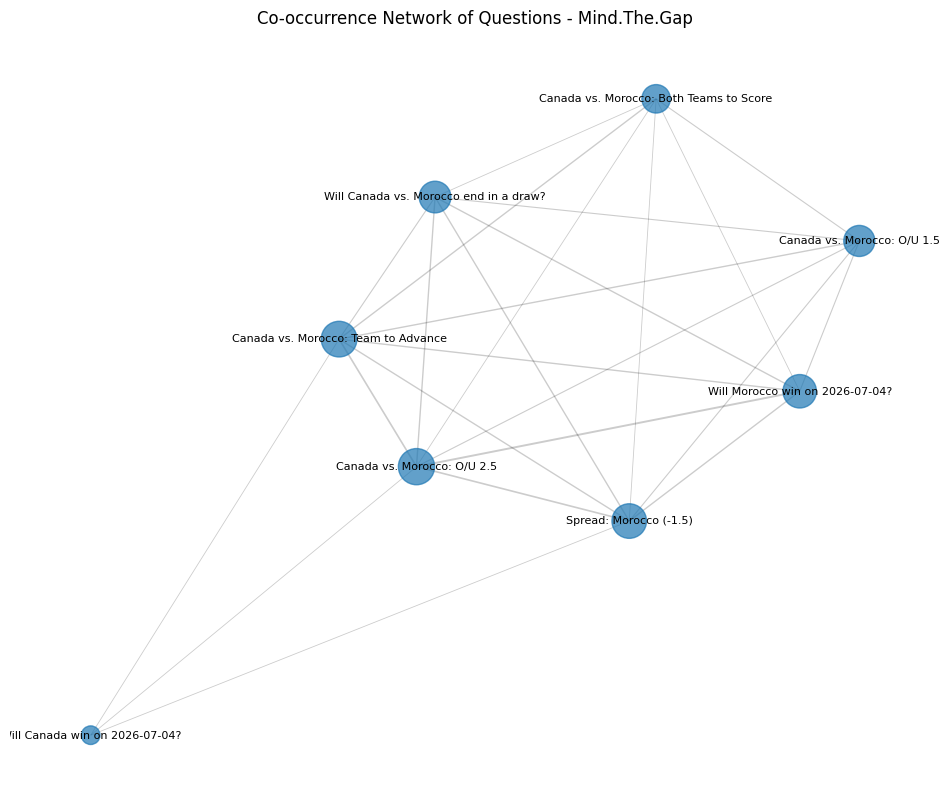


--- Top Nodes by Weighted Degree: RN1 ---
                                                   weighted_degree
Canada vs. Morocco: O/U 1.5                              271.00000
Will Morocco win on 2026-07-04?                          258.00000
Wimbledon ATP: Frances Tiafoe vs Alexander Bublik        242.00000
France leading at halftime?                              239.00000
Canada vs. Morocco: O/U 2.5                              224.00000
Exact Score: Canada 0 - 2 Morocco?                       222.00000
Exact Score: Canada 0 - 1 Morocco?                       214.00000
Canada vs. Morocco: Both Teams to Score                  203.00000
Canada vs. Morocco: O/U 3.5                              197.00000
Canada vs. Morocco: Team to Advance                      195.00000


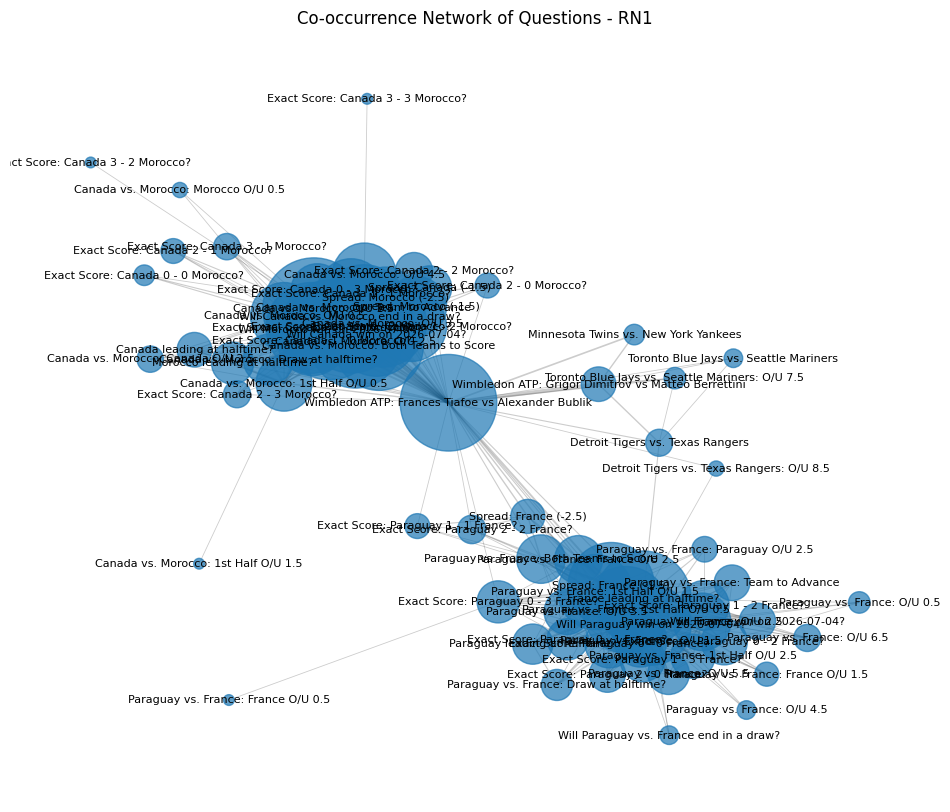

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    import networkx as nx
    HAS_NX = True
except ImportError:
    HAS_NX = False
    print("networkx not installed. Skipping network analysis.")

if HAS_NX:
    for wallet in fills['wallet_label'].unique():
        w_fills = fills[fills['wallet_label'] == wallet]
        # Create a transaction matrix (binary presence in a minute)
        binary_exposure = w_fills.pivot_table(
            index='minute_bucket',
            columns='question',
            values='fill_size',
            aggfunc=lambda x: 1 if len(x) > 0 else 0
        ).fillna(0)

        # Matrix multiplication to get co-occurrence counts
        adj_matrix = binary_exposure.T @ binary_exposure

        # Build Graph
        G = nx.Graph()
        questions = adj_matrix.columns

        for i in range(len(questions)):
            for j in range(i + 1, len(questions)):
                weight = adj_matrix.iloc[i, j]
                if weight >= 3: # Filter edges with count_pair >= 3
                    G.add_edge(questions[i], questions[j], weight=weight)

        if G.number_of_nodes() > 0:
            # Calculate Weighted Degree
            weighted_degrees = dict(G.degree(weight='weight'))
            degree_df = pd.DataFrame.from_dict(weighted_degrees, orient='index', columns=['weighted_degree'])
            degree_df = degree_df.sort_values('weighted_degree', ascending=False)

            print(f"\n--- Top Nodes by Weighted Degree: {wallet} ---")
            print(degree_df.head(10))

            # Plotting
            plt.figure(figsize=(12, 10))
            pos = nx.spring_layout(G, k=0.5, seed=42)

            # Draw nodes proportional to weighted degree
            node_sizes = [weighted_degrees[n] * 20 for n in G.nodes()]
            nx.draw_networkx_nodes(G, pos, node_size=node_sizes, alpha=0.7)
            nx.draw_networkx_edges(G, pos, alpha=0.2, width=[G[u][v]['weight']/5 for u,v in G.edges()])
            nx.draw_networkx_labels(G, pos, font_size=8, font_family='sans-serif')

            plt.title(f"Co-occurrence Network of Questions - {wallet}")
            plt.axis('off')
            plt.show()
        else:
            print(f"\nNo significant market co-occurrences (count >= 3) found for {wallet}.")